# Two-soliton collisions — particle-like scattering in the nonlinear Schrödinger equation

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 1 — Computational toolbox*

## 1. Introduction and motivation

Two small ripples crossing a harbour pass through each other and come out unchanged, because at small
amplitude the equation for water waves is *linear*. If $\psi_1$ and $\psi_2$ both solve a linear wave equation,
so does $\psi_1+\psi_2$, so the two waves never notice each other at all: the superposition is a solution from
the start, and "the collision" is a picture we draw on top of a sum that was always there.

Notebook [00c](00c_bright_soliton_imaginary_time_nonlinear_schroedinger.ipynb) left that world. The equation
of this notebook is

$$ i\,\frac{\partial\psi}{\partial t} \;=\; -\frac{1}{2}\frac{\partial^{2}\psi}{\partial x^{2}}
   \;-\; g\,\vert\psi\vert^{2}\psi , \tag{1} $$

the dimensionless Gross-Pitaevskii (nonlinear Schrödinger) equation, and it has no superposition principle.
The sum of two solutions is not a solution. Two lumps of matter described by Eq. (1) have every reason to
scatter off each other, deform, exchange particles, merge, or shatter into radiation — and in a generic
nonlinear medium they do.

Equation (1) is not generic. Two bright solitons launched at each other pass through, and afterwards each one
has exactly the shape, the norm and the velocity it had before. Nothing is radiated away, to the $10^{-5}$
resolution of the measurements below. The only record of the encounter is that each soliton is displaced from
where free motion would have put it, and that its internal phase has jumped. This is the property that gave
the objects their name: Zabusky and Kruskal, integrating the Korteweg-de Vries equation numerically in 1965,
found solitary waves that survived collisions like particles and coined the word *soliton* for them
(Phys. Rev. Lett. **15**, 240 (1965)). Zakharov and Shabat proved in 1972 that Eq. (1) has the same structure:
it is integrable, solvable by inverse scattering, and its solitons scatter elastically for ever
(Sov. Phys. JETP **34**, 62 (1972)).

The experiments are real. In an optical fibre the same equation governs a light pulse (Section 2.4 of 00c;
Agrawal, *Nonlinear Fiber Optics*, Chapter 5), and
soliton collisions in fibres are a design constraint for long-haul transmission: neighbouring pulses in a bit
stream attract or repel depending on their relative phase, which is precisely what Gordon computed in 1983
(Opt. Lett. **8**, 596 (1983)). With atoms, Nguyen, Dyke, Luo, Malomed and Hulet collided matter-wave solitons
made of lithium-7 with a controlled *relative phase*, which is what decides what happens at the moment of
overlap: in-phase solitons build a density spike, out-of-phase solitons keep a node between them and never touch
(Nature Physics **10**, 918 (2014)). In three dimensions that spike matters, because a dense enough attractive
condensate collapses, so a collision that is elastic in the integrable one-dimensional model can destroy both
solitons in the laboratory. Section 9 reproduces that mechanism in one dimension by adding a term that breaks
integrability.

### Road map

* **Section 2** — the initial state: two boosted solitons of norm fractions $N_1$, $N_2$ at $\mp x_0$ with
  velocities $k_1$, $k_2$ and relative phase $\Delta\phi$; why their sum is an almost-exact solution and
  exactly how "almost" is measured.
* **Section 3** — norm, momentum and energy as the referee of every run in this notebook.
* **Section 4** — the collision itself: space-time maps, and the measurement that each soliton comes out with
  its shape, norm and velocity unchanged.
* **Section 5** — the position shift and the phase shift, measured as functions of the relative velocity and
  compared with the inverse-scattering result.
* **Section 6** — the relative phase: what changes during the collision (everything one can see) and what does
  not (the outcome). A `vmap` over $\Delta\phi$.
* **Section 7** — two solitons at rest: the exponential interaction force and its $\cos\Delta\phi$, measured.
* **Section 8** — unequal solitons and the centre-of-mass sum rule.
* **Section 9** — breaking integrability with a quintic term and with a barrier: radiation, norm transfer,
  merging.
* **Section 10** — resolution, time step, and the periodic ring.
* **Section 11** — animations and space-time maps.
* **Section 12** — summary, exercises, references.

### What you will learn

*Physics*

* what elastic scattering of solitons means quantitatively, and how to demonstrate it rather than assert it;
* the position shift and the phase shift left by a collision, their dependence on the relative velocity, and
  why the shift is *forward* for an attractive nonlinearity;
* the role of the relative phase: an interference pattern during the overlap, and nothing in the outcome;
* the exponential force between neighbouring solitons and its sinusoidal phase dependence;
* what integrability buys, and what happens to collisions when a small term takes it away.

*Numerical methods*

* tracking several moving objects in one field: windowed centroids, and why the window must be re-centred;
* extracting an asymptotic scattering datum (a shift) from a finite-time simulation by fitting the incoming
  and outgoing asymptotes;
* resolution requirements for fast solitons from the sampling theorem, convergence in $\Delta t$ and
  $\Delta x$, and the periodic-ring recurrence that sets the largest usable time.

*Implementation practice*

* `jax.vmap` over relative phases, over separations and over time steps, to run whole parameter sweeps as one
  compiled program;
* reusing a propagator written in an earlier notebook without rewriting or re-deriving it;
* a perturbed propagator built by changing one line of the split-step body.

### Prerequisites

[00c — bright solitons](00c_bright_soliton_imaginary_time_nonlinear_schroedinger.ipynb) is essential: the
soliton profile, the Galilean boost, the conserved quantities and the split-step Fourier propagator are all
taken from it and are not re-derived here.
[00a — a free Gaussian wave packet on a ring](00a_free_particle_gaussian_wave_packet.ipynb) supplies the
periodic grid, `fftfreq` and the sampling theorem, and
[00b — the harmonic oscillator](00b_first_quantum_simulation_harmonic_oscillator.ipynb) the habit of checking
an integrator before believing it. One semester of quantum mechanics. The three JAX features used here
(`jit`, `lax.scan`, `vmap`) are each explained in two sentences where they appear and properly in
[01 — JAX](01_jax_from_scratch.ipynb).

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # the 52 einsum index labels a-z, A-Z

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Two solitons on one ring

### 2.1 The one-soliton family of notebook 00c

Notebook 00c derived the stationary solutions of Eq. (1) on the infinite line. With the normalisation left
free, the family is (Eq. (25) of 00c)

$$ \phi_N(x) \;=\; \frac{N\sqrt g}{2}\;\mathrm{sech}\!\left[\kappa_N\,(x-x_c)\right] , \qquad
   \kappa_N \;\equiv\; \frac{Ng}{2} , \qquad
   \int\vert\phi_N\vert^{2}dx \;=\; N , \tag{2} $$

with chemical potential $\mu_N = -\kappa_N^{2}/2 = -(Ng)^{2}/8$. Three numbers follow from Eq. (2) and will be
used constantly:

| quantity | value | for $N=\tfrac12$, $g=2$ |
|---|---|---|
| amplitude decay length ("width") | $1/\kappa_N = 2/(Ng)$ | $2$ |
| peak amplitude | $\kappa_N/\sqrt g = N\sqrt g/2$ | $0.35355$ |
| peak density | $\kappa_N^{2}/g = N^{2}g/4$ | $0.125$ |

Because the whole notebook keeps the *total* norm equal to one, a pair of solitons must share it:
$N_1+N_2 = 1$. Two equal solitons therefore have $N_1 = N_2 = \tfrac12$, hence $\kappa = g/4 = 0.5$ at $g=2$,
a width $1/\kappa = 2$ and a peak density $0.125$ — each of them *twice* as wide as the single unit-norm
soliton of 00c ($\kappa=1$, width $1$, peak density $0.5$), and each four times less dense. The relation
$\kappa_N \propto N$ is the statement that a soliton made of fewer atoms is wider and flatter, and the physical soliton that a
laboratory makes is set by $N_jg$, not by $g$ alone.

The Galilean boost of 00c (its Eq. (26)) turns a stationary profile into a moving one:

$$ \psi_j(x,t) \;=\; \phi_{N_j}\!\left(x - x_j - k_j t\right)\,
   \exp\!\left[\,i k_j x - i\left(\tfrac{k_j^{2}}{2}+\mu_{N_j}\right)t + i\varphi_j\right] , \tag{3} $$

an exact solution of Eq. (1) for every $k_j$, every centre $x_j$ and every constant phase $\varphi_j$.

### 2.2 The initial state, and why a sum is almost a solution

We start from the sum of two such solutions at $t=0$, separated by $2x_0$:

$$ \psi(x,0) \;=\; \phi_{N_1}(x+x_0)\,e^{ik_1x} \;+\; e^{i\Delta\phi}\,\phi_{N_2}(x-x_0)\,e^{ik_2x} . \tag{4} $$

Equation (1) is not linear, so Eq. (4) is **not** an exact solution. Substituting a sum $\psi_1+\psi_2$ into Eq. (1) leaves a residual which is a sum of cross terms, every
one of which contains a product of the two profiles:

$$ i\partial_t(\psi_1+\psi_2) + \tfrac12\partial_x^2(\psi_1+\psi_2) + g\vert\psi_1+\psi_2\vert^{2}(\psi_1+\psi_2)
   \;=\; g\left[2\vert\psi_1\vert^{2}\psi_2 + \psi_1^{2}\psi_2^{*}
   \;+\; 2\vert\psi_2\vert^{2}\psi_1 + \psi_2^{2}\psi_1^{*}\right] , \tag{5} $$

because the linear parts cancel separately for $\psi_1$ and for $\psi_2$. Every term on the right contains
both profiles, and the profiles decay as $e^{-\kappa_1\vert x+x_0\vert}$ and $e^{-\kappa_2\vert x-x_0\vert}$.
Between the centres that product is a single exponential in $x$, so it is largest at one of the two centres,
where it equals $e^{-\kappa_2 d}$ (at $-x_0$) and $e^{-\kappa_1 d}$ (at $+x_0$). The larger of the two, and
therefore the size of the whole residual, is of order

$$ e^{-\kappa_{\min}\,d} , \qquad d \equiv 2x_0 \ \text{(the separation)}, \qquad
   \kappa_{\min} = \min(\kappa_1,\kappa_2) . \tag{6} $$

So Eq. (4) is an exact solution up to an error that is *exponentially small in the separation*, and every
statement in this notebook that compares a measurement with an infinite-line formula carries that error as its
floor. Section 2.4 measures it; Section 10 shows what happens when $x_0$ is chosen too small.

### 2.3 What the relative phase means

Two things about $\Delta\phi$ in Eq. (4) need saying before it is used.

First, for the **symmetric** setup $N_1=N_2=N$, $k_1=-k_2=k$, $\Delta\phi$ is also the relative phase *at the
moment of collision*. The two solitons meet at $x=0$ at $t_c\approx x_0/k$, and by Eq. (3) their phases there
are $-\left(\tfrac{k^{2}}{2}+\mu_N\right)t_c$ and the same plus $\Delta\phi$: the two internal phases wind at
exactly the same rate because $k_1^{2}=k_2^{2}$ and $\mu_{N_1}=\mu_{N_2}$. The relative phase is therefore
constant, and equal to $\Delta\phi$, right up to the collision. For unequal solitons it is not, and the phase
at the collision has to be computed.

Second, the symmetric state has a definite **parity**. Using $\phi(-u)=\phi(u)$,

$$ \psi(-x,0) \;=\; \phi_N(x-x_0)e^{-ikx} + e^{i\Delta\phi}\phi_N(x+x_0)e^{ikx}
   \;=\; e^{i\Delta\phi}\left[\phi_N(x+x_0)e^{ikx} + e^{-i\Delta\phi}\phi_N(x-x_0)e^{-ikx}\right] , $$

which for $\Delta\phi = 0$ equals $+\psi(x,0)$ and for $\Delta\phi = \pi$ equals $-\psi(x,0)$. Equation (1) is
invariant under $x\to-x$, so parity is conserved exactly, and an odd state satisfies $\psi(0,t)=0$ **for all
$t$**. The node that Section 6 finds between out-of-phase solitons is therefore exact, and it holds during
the whole collision.

In [2]:
# ==============================================================================
# EXTRA IMPORTS  -- everything else comes from the Configuration cell above
# ==============================================================================
import base64                                   # to inline the animated GIFs in the notebook output
import tempfile                                 # a scratch file for each GIF (deleted immediately)

from matplotlib.animation import FuncAnimation, PillowWriter   # GIF writing
from IPython.display import display                            # embed the GIF in the notebook output

# colour-blind-friendly palette, used consistently in every figure of this notebook
C_NUM, C_ANA, C_THIRD, C_FOURTH, C_GREY = "#0072B2", "#D55E00", "#009E73", "#CC79A7", "0.45"

print("extra imports OK")

extra imports OK


### 2.4 The grid and the functions taken over from notebook 00c

The next cell is bookkeeping: the grid, the exact one-soliton solution, the energy functional, the
observables and the split-step propagator, all copied verbatim from
[00c](00c_bright_soliton_imaginary_time_nonlinear_schroedinger.ipynb), each with a one-line pointer to where
it was derived (the FFT and operator splitting are treated in Press *et al.*, *Numerical Recipes*, Chapters 12
and 20, with array-based Fortran 90 routines in the companion volume).

> **JAX practice.** `jax.jit` compiles a Python function once, for the shapes of its arguments, into a single
> fused program, and `lax.scan(body, init, xs, length=n)` is a compiled `for` loop that carries a state
> forward. Both are used exactly as in 00c and are explained properly in
> [01 — JAX](01_jax_from_scratch.ipynb).

In [3]:
# ==============================================================================
# STEP 1: everything inherited from notebook 00c  (grid, exact soliton, energetics)
# ==============================================================================
def make_grid(L, N_x):
    """Centred periodic grid on [-L/2, L/2) and the matching FFT wave numbers -- derived in notebook 00c.

    MATH
        x_j = (j - N_x/2) dx,  j = 0..N_x-1,  dx = L / N_x
        k_n = 2 pi n / L in np.fft.fft order
    """
    dx = L / N_x
    x = (np.arange(N_x) - N_x // 2) * dx
    k = 2.0 * np.pi * np.fft.fftfreq(N_x, d=dx)
    return x, k, dx


def soliton_exact(x, t=0.0, g=2.0, x_c=0.0, k_0=0.0, n=1.0):
    """Bright soliton of norm n, boosted to velocity k_0 -- derived in notebook 00c (Eqs. (25), (26) there).

    MATH
        kappa = n g / 2,   mu = -kappa^2 / 2,   amplitude = kappa / sqrt(g)
        psi(x,t) = (kappa/sqrt(g)) sech[kappa (x - x_c - k_0 t)] exp( i k_0 x - i (k_0^2/2 + mu) t )
        integral |psi|^2 dx = n
    """
    kappa = n * g / 2.0
    mu = -0.5 * kappa ** 2
    u = np.clip(kappa * (x - x_c - k_0 * t), -700.0, 700.0)
    envelope = (kappa / np.sqrt(g)) / np.cosh(u)
    phase = np.exp(1j * (k_0 * x - (0.5 * k_0 ** 2 + mu) * t))
    return (envelope * phase).astype(CDTYPE)


def d_dx(psi, k):
    """Spectral first derivative -- derived in notebook 00a:  psi' = IFFT[ i k FFT[psi] ]."""
    return np.fft.ifft(1j * k * np.fft.fft(psi))


def d2_dx2(psi, k):
    """Spectral second derivative -- derived in notebook 00a:  psi'' = IFFT[ -k^2 FFT[psi] ]."""
    return np.fft.ifft(-(k ** 2) * np.fft.fft(psi))


def gp_hamiltonian(psi, k, g, V=0.0):
    """Apply the Gross-Pitaevskii operator -- derived in notebook 00c:  -(1/2) psi'' - g|psi|^2 psi + V psi."""
    return -0.5 * d2_dx2(psi, k) - g * np.abs(psi) ** 2 * psi + V * psi


def gp_energy(psi, k, dx, g, V=0.0, parts=False):
    """Energy of the field -- derived in notebook 00c.

    MATH
        E = dx sum_j [ (1/2)|psi'_j|^2 - (g/2)|psi_j|^4 + V_j |psi_j|^2 ]
    NOTE
        With the total norm fixed to 1 this is the energy per particle in units of E_0.
    """
    e_kin = float(dx * np.sum(0.5 * np.abs(d_dx(psi, k)) ** 2).real)
    e_int = float(dx * np.sum(-0.5 * g * np.abs(psi) ** 4))
    e_pot = float(dx * np.sum(V * np.abs(psi) ** 2))
    return (e_kin, e_int, e_pot) if parts else e_kin + e_int + e_pot


def gp_chemical_potential(psi, k, dx, g, V=0.0):
    """mu = <psi| H_GP[psi] |psi> for a normalised psi -- derived in notebook 00c."""
    return float(dx * np.sum(np.conj(psi) * gp_hamiltonian(psi, k, g, V)).real)


def grid_norm(psi, dx):
    """Norm squared:  dx sum_j |psi_j|^2  -- notebook 00a."""
    return float(dx * np.sum(np.abs(psi) ** 2))


def mean_position(psi, x, dx, L):
    """Circular mean of |psi|^2 -- notebook 00c.  Meaningful only for a state confined to much less than L."""
    w = np.abs(psi) ** 2 * dx
    z = np.sum(w * np.exp(2j * np.pi * x / L))
    return float(np.angle(z)) * L / (2.0 * np.pi)


def mean_momentum(psi, k):
    """Momentum PER PARTICLE, evaluated in Fourier space -- notebook 00c.

    MATH
        <p>/N = sum_n k_n |psi_hat_n|^2 / sum_n |psi_hat_n|^2
    NOTE
        The weights are normalised, so this equals <psi| -i d/dx |psi> only for a state of unit norm;
        multiply by the norm to obtain the total momentum (as CHECKPOINT 1 below does).
    """
    weights = np.abs(np.fft.fft(psi)) ** 2
    return float(np.sum(k * weights) / np.sum(weights))


def _split_step_body(k, g, V, dt):
    """One Strang step in real time -- derived in notebook 00c. Each factor has modulus one."""
    exp_kin = jnp.exp(-0.25j * k ** 2 * dt)             # exp(-i (k^2/2)(dt/2))

    def step(psi, _):
        psi = jnp.fft.ifft(exp_kin * jnp.fft.fft(psi))                  # kinetic half step
        psi = psi * jnp.exp(1j * (g * jnp.abs(psi) ** 2 - V) * dt)      # nonlinear + potential full step
        return jnp.fft.ifft(exp_kin * jnp.fft.fft(psi)), None           # kinetic half step
    return step


@partial(jax.jit, static_argnames=("n_steps",))
def split_step_evolve(psi, k, g, V, dt, n_steps):
    """Propagate by n_steps * dt with the unitary Strang split-step Fourier method -- notebook 00c.

    COST
        2 FFTs per step, O(N_x log N_x); no stability limit, the step is chosen by accuracy alone.
    """
    return lax.scan(_split_step_body(k, g, V, dt), psi, None, length=n_steps)[0]


@partial(jax.jit, static_argnames=("n_inner", "n_frames"))
def split_step_frames(psi, k, g, V, dt, n_inner, n_frames):
    """Same propagation, returning a snapshot every n_inner steps: shape (n_frames+1, N_x) -- notebook 00c."""
    step = _split_step_body(k, g, V, dt)

    def outer(psi, _):
        psi, _ = lax.scan(step, psi, None, length=n_inner)
        return psi, psi

    _, frames = lax.scan(outer, psi, None, length=n_frames)
    return jnp.concatenate([psi[None, :], frames], axis=0)


print("STEP 1: inherited from 00c -->", ", ".join(
    ["make_grid", "soliton_exact", "gp_energy", "gp_chemical_potential", "mean_position", "mean_momentum",
     "split_step_evolve", "split_step_frames"]))

STEP 1: inherited from 00c --> make_grid, soliton_exact, gp_energy, gp_chemical_potential, mean_position, mean_momentum, split_step_evolve, split_step_frames


### 2.5 The parameters of the main experiment, and the initial state

The ring has to hold two solitons that start far apart, collide, and separate again without either of them
meeting the other one round the back. With $L = 120$, a half-separation $x_0 = 20$ and $\kappa = 0.5$ the
overlap parameter of Eq. (6) is $e^{-\kappa\cdot 2x_0} = e^{-20} \approx 2\times10^{-9}$, and the image of
each soliton across the seam sits $L-2x_0 = 80$ length units from its partner, i.e. $e^{-40}$ away. The
resolution $\Delta x = L/N_x$ is discussed in Section 10; $N_x = 1024$ gives a Nyquist wave number
$\pi/\Delta x = 26.8$, far above anything the solitons carry.

In [4]:
# ==============================================================================
# PARAMETERS of the main experiment  (change them and re-run the whole notebook)
# ==============================================================================
G      = 2.0        # dimensionless coupling, attractive           (00c, Section 3.3)
L      = 120.0      # circumference of the ring                    [x_0]
N_X    = 1024       # number of grid points                        [-]
N_1    = 0.5        # norm fraction of the left soliton            [-]
N_2    = 0.5        # norm fraction of the right soliton           [-]
X0     = 20.0       # each soliton starts at -X0 / +X0             [x_0]
M_MAIN = 8          # main collision: k = 2 pi M_MAIN / L          (commensurate with the ring, rule 1 of 00a)
DT     = 0.005      # real-time step for the showcase runs         [t_0]

x, k, dx = make_grid(L, N_X)
k_j = jnp.asarray(k)
V_ZERO = jnp.zeros(N_X, dtype=RDTYPE)

KAP_1, KAP_2 = N_1 * G / 2, N_2 * G / 2          # inverse widths, Eq. (2)
K_MAIN = 2.0 * np.pi * M_MAIN / L                # velocity of the left soliton; the right one has -K_MAIN

print(f"grid      : L = {L:g}, N_x = {N_X}, dx = {dx:.6f}, Nyquist k = {np.pi / dx:.3f}")
print(f"solitons  : N_1 = {N_1:g}, N_2 = {N_2:g} -> kappa = {KAP_1:g}, {KAP_2:g}; "
      f"widths 1/kappa = {1 / KAP_1:g}, {1 / KAP_2:g}")
print(f"            peak density kappa^2/g = {KAP_1 ** 2 / G:.6f}, mu = -kappa^2/2 = {-KAP_1 ** 2 / 2:.6f}")
print(f"geometry  : x_0 = {X0:g}, separation d = {2 * X0:g}, overlap exp(-kappa d) = {np.exp(-KAP_1 * 2 * X0):.3e}")
print(f"            image across the seam: L - d = {L - 2 * X0:g}, exp(-kappa (L-d)) = "
      f"{np.exp(-KAP_1 * (L - 2 * X0)):.3e}")
print(f"velocity  : k = 2 pi {M_MAIN} / L = {K_MAIN:.6f}, relative velocity 2k = {2 * K_MAIN:.6f}")
print(f"            free collision time x_0/k = {X0 / K_MAIN:.3f}, run length T = 2 x_0/k = {2 * X0 / K_MAIN:.3f}")

grid      : L = 120, N_x = 1024, dx = 0.117188, Nyquist k = 26.808
solitons  : N_1 = 0.5, N_2 = 0.5 -> kappa = 0.5, 0.5; widths 1/kappa = 2, 2
            peak density kappa^2/g = 0.125000, mu = -kappa^2/2 = -0.125000
geometry  : x_0 = 20, separation d = 40, overlap exp(-kappa d) = 2.061e-09
            image across the seam: L - d = 80, exp(-kappa (L-d)) = 4.248e-18
velocity  : k = 2 pi 8 / L = 0.418879, relative velocity 2k = 0.837758
            free collision time x_0/k = 47.746, run length T = 2 x_0/k = 95.493


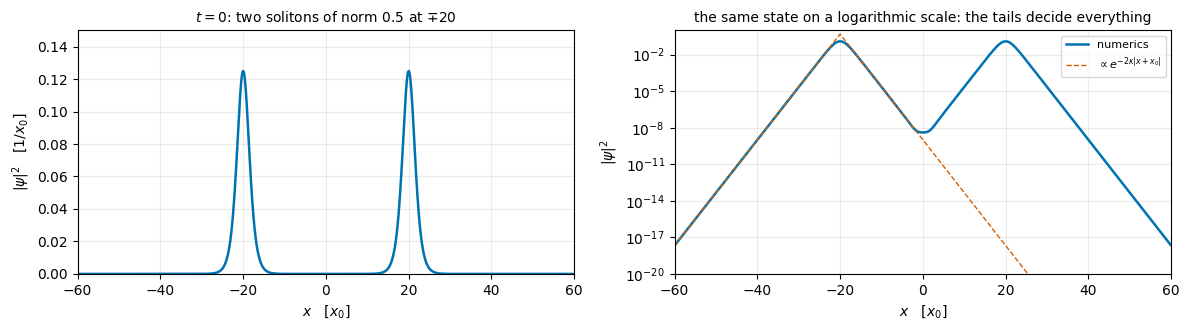

peak density (sampled): 0.12495233   analytic kappa^2/g = 0.12500000   (the maximum falls between two grid points)
density midway        : 4.122e-09   analytic 16 (kappa^2/g) exp(-2 kappa x_0) = 4.122e-09


In [5]:
# ==============================================================================
# STEP 2: the two-soliton initial state, Eq. (4)
# ==============================================================================
def two_solitons(x, x_0, g=2.0, n_1=0.5, n_2=0.5, k_1=0.0, k_2=0.0, d_phi=0.0):
    """Sum of two boosted solitons, Eq. (4): centres -x_0 and +x_0, relative phase d_phi.

    MATH
        psi(x,0) = phi_{n1}(x + x_0) exp(i k_1 x) + exp(i d_phi) phi_{n2}(x - x_0) exp(i k_2 x)
    IMPLEMENTATION
        Each term is soliton_exact at t = 0, so the profile, the amplitude and the boost phase all come
        from the single formula validated in notebook 00c.
    ACCURACY
        NOT an exact solution of Eq. (1): the residual is O(exp(-kappa_min * 2 x_0)), Eqs. (5)-(6).
    """
    left = soliton_exact(x, 0.0, g, x_c=-x_0, k_0=k_1, n=n_1)
    right = soliton_exact(x, 0.0, g, x_c=+x_0, k_0=k_2, n=n_2)
    return (left + np.exp(1j * d_phi) * right).astype(CDTYPE)


psi0_main = two_solitons(x, X0, G, N_1, N_2, K_MAIN, -K_MAIN, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 3.4))
axes[0].plot(x, np.abs(psi0_main) ** 2, color=C_NUM, lw=1.8)
axes[0].set_xlim(-L / 2, L / 2), axes[0].set_ylim(0, 0.15)
axes[0].set_xlabel(r"$x$   [$x_0$]"), axes[0].set_ylabel(r"$|\psi|^2$   [$1/x_0$]")
axes[0].set_title(rf"$t=0$: two solitons of norm ${N_1:g}$ at $\mp{X0:g}$", fontsize=10)
axes[0].grid(alpha=0.25)
axes[1].semilogy(x, np.abs(psi0_main) ** 2 + 1e-300, color=C_NUM, lw=1.8, label="numerics")
axes[1].semilogy(x, np.exp(-2 * KAP_1 * np.abs(x + X0)) * KAP_1 ** 2 / G * 4, "--", color=C_ANA, lw=1.0,
                 label=r"$\propto e^{-2\kappa|x+x_0|}$")
axes[1].set_xlim(-L / 2, L / 2), axes[1].set_ylim(1e-20, 1.0)
axes[1].set_xlabel(r"$x$   [$x_0$]"), axes[1].set_ylabel(r"$|\psi|^2$")
axes[1].set_title("the same state on a logarithmic scale: the tails decide everything", fontsize=10)
axes[1].grid(alpha=0.25), axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"peak density (sampled): {np.max(np.abs(psi0_main) ** 2):.8f}   analytic kappa^2/g = "
      f"{KAP_1 ** 2 / G:.8f}   (the maximum falls between two grid points)")
# midway, sech(u) -> 2 exp(-u), the two tails add in phase and the boost phases are 1 at x = 0:
# amplitude 2 x 2 (kappa/sqrt g) exp(-kappa x_0)  ->  density 16 (kappa^2/g) exp(-2 kappa x_0)
print(f"density midway        : {np.abs(psi0_main[N_X // 2]) ** 2:.3e}   "
      f"analytic 16 (kappa^2/g) exp(-2 kappa x_0) = {16 * KAP_1 ** 2 / G * np.exp(-2 * KAP_1 * X0):.3e}")

The left panel is what the experiment looks like: two identical lumps of peak density $0.125$, sitting $40$
length units apart on a ring of circumference $120$. (The *sampled* peak printed under the figure is
$0.12495$, not $0.125$: the maximum of the $\mathrm{sech}$ falls between two grid points, since $x_0=20$ is
not a multiple of $\Delta x = 0.1172$.) The right panel is the same state with a logarithmic vertical axis,
and it is the panel that matters for everything below. The density between the two solitons falls to
$4\times10^{-9}$ — exactly the $16(\kappa^{2}/g)e^{-2\kappa x_0}$ that two overlapping $\mathrm{sech}$
tails predict, printed under the figure — and the dashed line is the analytic tail
$e^{-2\kappa\vert x+x_0\vert}$ of the left soliton alone. The two agree over eighteen decades, which is the
statement that on this ring each soliton is an isolated object to a part in $10^{9}$.

### 2.6 The deviation of the two-soliton sum from a solution

The quantitative version of Eq. (6). Three quantities are compared with the value they would have if the two
solitons were infinitely far apart, where the sum *would* be exact:

$$ \mathcal{N} = \sum_j N_j = 1, \qquad
   p \;=\; \int \psi^{*}(-i\partial_x)\psi\,dx \;=\; \sum_j N_j k_j , \qquad
   E \;=\; \sum_j\left[-\frac{\kappa_j^{3}}{3g} + \frac{N_jk_j^{2}}{2}\right] . \tag{7} $$

The energy of one soliton comes straight from 00c: for norm $N$ it found
$E_{\rm kin} = \kappa_N^{3}/(3g)$ and $E_{\rm int} = -2\kappa_N^{3}/(3g)$, whose sum is $-\kappa_N^{3}/(3g)$,
and the boost adds $N k^{2}/2$ because $\vert\psi'\vert^{2} = (\phi')^{2}+k^{2}\phi^{2}$ and
$\int\phi^{2}=N$. For $N=\tfrac12$, $g=2$ that is $-0.0208\overline{3}$ per soliton.

The cell below sweeps $x_0$ and prints the deviation of each of the three from Eq. (7).

In [6]:
# ==============================================================================
# CHECKPOINT 1: the two-soliton sum is a solution up to exp(-kappa * separation)
# ==============================================================================
def pair_reference(g, n_list, k_list):
    """Norm, momentum and energy of a pair of INFINITELY SEPARATED boosted solitons -- Eq. (7)."""
    norm = sum(n_list)
    mom = sum(n * kk for n, kk in zip(n_list, k_list))
    ene = sum(-((n * g / 2) ** 3) / (3 * g) + 0.5 * n * kk ** 2 for n, kk in zip(n_list, k_list))
    return norm, mom, ene


ref_N, ref_p, ref_E = pair_reference(G, [N_1, N_2], [K_MAIN, -K_MAIN])
print(f"infinitely separated pair:  norm = {ref_N:.10f}   p = {ref_p:.10f}   E = {ref_E:.10f}")
print(f"\n{'x_0':>6s} {'d = 2 x_0':>10s} {'norm - 1':>12s} {'E - E_ref':>12s} {'p - p_ref':>12s} "
      f"{'exp(-kappa d)':>14s}")
d_scan, dev_E = [], []
for x0_try in (5.0, 10.0, 15.0, 20.0, 25.0, 30.0):
    p_try = two_solitons(x, x0_try, G, N_1, N_2, K_MAIN, -K_MAIN, 0.0)
    dn = grid_norm(p_try, dx) - ref_N
    de = gp_energy(p_try, k, dx, G) - ref_E
    dp = mean_momentum(p_try, k) * grid_norm(p_try, dx) - ref_p
    d_scan.append(2 * x0_try), dev_E.append(abs(de))
    print(f"{x0_try:6.1f} {2 * x0_try:10.1f} {dn:12.3e} {de:12.3e} {dp:12.3e} "
          f"{np.exp(-KAP_1 * 2 * x0_try):14.3e}")

# the cross term carries the factor exp(2 i k x_0), so its SIGN oscillates with the separation and
# consecutive ratios are noisy; the exponential ENVELOPE is what Eq. (6) predicts, so fit the slope.
slope_d = np.polyfit(np.array(d_scan), np.log(np.array(dev_E)), 1)[0]
print(f"\nfitted slope of ln|E - E_ref| against the separation d: {slope_d:+.4f}")
print(f"predicted -kappa = {-KAP_1:+.4f}")
assert abs(slope_d + KAP_1) < 0.02, "the residual of the sum must fall as exp(-kappa d)"
assert abs(grid_norm(psi0_main, dx) - 1) < 1e-8
print("\nCHECKPOINT 1 passed: the deviations fall like exp(-kappa d), Eq. (6).")

infinitely separated pair:  norm = 1.0000000000   p = 0.0000000000   E = 0.0460631502

   x_0  d = 2 x_0     norm - 1    E - E_ref    p - p_ref  exp(-kappa d)
   5.0       10.0   -5.303e-03    2.334e-03   -2.602e-17      6.738e-03
  10.0       20.0    3.573e-05   -9.587e-06    0.000e+00      4.540e-05
  15.0       30.0   -2.220e-16   -5.822e-08   -1.041e-16      3.059e-07
  20.0       40.0   -1.622e-09    8.258e-10    0.000e+00      2.061e-09
  25.0       50.0    1.093e-11   -2.921e-12   -5.204e-17      1.389e-11
  30.0       60.0   -9.392e-14   -3.702e-14    0.000e+00      9.358e-14

fitted slope of ln|E - E_ref| against the separation d: -0.4960
predicted -kappa = -0.5000

CHECKPOINT 1 passed: the deviations fall like exp(-kappa d), Eq. (6).


The deviations fall by about eleven orders of magnitude as the separation grows from $10$ to $60$, and the
fitted slope of $\ln\vert E-E_{\rm ref}\vert$ against $d$ is $-0.4960$ against the predicted $-\kappa =
-0.5$. The individual ratios between consecutive rows are *not* uniform, and should not be expected to be:
the cross term carries the boost factor $e^{2ikx_0}$, so its sign oscillates as the separation grows and its
magnitude is an oscillation inside an exponential envelope. It is the envelope that Eq. (6) predicts, and the
fitted slope is the way to test it. The near-cancellation at $x_0=15$, where the norm deviation drops to
$2\times10^{-16}$, is one of those sign changes caught in the act.

At the working separation $d = 40$ the norm is $1$ to $1.6\times10^{-9}$ and the energy agrees with Eq. (7)
to $8\times10^{-10}$. The momentum is exact to round-off at every separation, because the cross term in $p$
cancels identically for the symmetric configuration $N_1=N_2$, $k_1=-k_2$.

Those numbers are the error floor of everything that follows: no comparison with an infinite-line formula in
this notebook can be better than $10^{-9}$. The measurements of Section 5 stay well above that floor, because
the trajectory fits and the time step limit them first (Section 10.2).

## 3. The conserved quantities

Section 4 of 00c derived three conservation laws for Eq. (1): the norm, the momentum
$p = \int\mathrm{Im}(\psi^{*}\psi')dx$ and the energy

$$ E[\psi] \;=\; \int\left[\frac{1}{2}\vert\psi'\vert^{2} - \frac{g}{2}\vert\psi\vert^{4}\right]dx . \tag{8} $$

Their value here is different from their value in 00c. There, the state was a single soliton whose exact
solution was known, so the conservation laws were a bonus. Here there is no closed form on the ring for what
the field does during the overlap, the initial state is not exactly a solution, and the whole question is
whether an elaborate nonlinear rearrangement leaves the two objects intact. The conserved quantities are then
the only *independent* referee available, and only one of the three is independent of the integrator:

* the **norm** is conserved by construction, because each of the three factors of the Strang step has
  modulus one;
* the **momentum** is conserved by construction as well: the kinetic factors leave every
  $\vert\hat\psi_k\vert$ unchanged, and the nonlinear phase changes $p$ by
  $g\Delta t\int\vert\psi\vert^{2}\partial_x\vert\psi\vert^{2}dx = 0$. Their constancy proves only that
  the code has no bug;
* the **energy** is not built into the method. Strang splitting nearly conserves a modified energy that differs
  from Eq. (8) at $O(\Delta t^{2})$, so $E$ drifts at that order, and a larger drift means the run is wrong.

A fourth quantity is worth watching for a two-body problem: the centre of mass. Ehrenfest's relation survives
the nonlinearity (00c, Eq. (14)), $d\langle x\rangle/dt = p$, so with $p$ conserved the centre of mass moves
in a straight line through the collision no matter what happens during it. Section 8 turns that into a sum
rule that the two position shifts must obey.

In [7]:
# ==============================================================================
# THE MAIN RUN: two equal solitons, in phase, colliding head-on
# ==============================================================================
T_MAIN = 2.0 * X0 / K_MAIN                       # the pair ends as far apart as it started
N_FRAMES = 200
n_inner_main = int(round((T_MAIN / N_FRAMES) / DT))
dt_main = (T_MAIN / N_FRAMES) / n_inner_main
t_main = np.arange(N_FRAMES + 1) * (T_MAIN / N_FRAMES)

t_wall = time.time()
fr_main = np.asarray(split_step_frames(jnp.asarray(psi0_main), k_j, G, V_ZERO,
                                       dt_main, n_inner_main, N_FRAMES))
print(f"{n_inner_main * N_FRAMES} split-step iterations (compile + run): {time.time() - t_wall:.2f} s")
print(f"T = {T_MAIN:.3f}, dt = {dt_main:.6f}, {N_FRAMES} snapshots every {T_MAIN / N_FRAMES:.4f}")

norm_t = np.array([grid_norm(p, dx) for p in fr_main])
E_t = np.array([gp_energy(p, k, dx, G) for p in fr_main])
p_t = np.array([mean_momentum(p, k) for p in fr_main])
print(f"\nconservation over the whole collision:")
print(f"   max |norm(t) - norm(0)| = {np.max(np.abs(norm_t - norm_t[0])):.3e}")
print(f"   max |E(t)    - E(0)|    = {np.max(np.abs(E_t - E_t[0])):.3e}   (E(0) = {E_t[0]:.10f}, "
      f"Eq. (7) gives {ref_E:.10f})")
print(f"   max |p(t)    - p(0)|    = {np.max(np.abs(p_t - p_t[0])):.3e}   (p(0) = {p_t[0]:.3e})")
assert np.max(np.abs(norm_t - norm_t[0])) < 1e-9
assert np.max(np.abs(E_t - E_t[0])) < 1e-5
assert np.max(np.abs(p_t - p_t[0])) < 1e-9
print("CHECKPOINT 2 passed: norm, energy and momentum survive the collision.")

19000 split-step iterations (compile + run): 0.93 s
T = 95.493, dt = 0.005026, 200 snapshots every 0.4775

conservation over the whole collision:
   max |norm(t) - norm(0)| = 1.751e-12
   max |E(t)    - E(0)|    = 3.195e-07   (E(0) = 0.0460631511, Eq. (7) gives 0.0460631502)
   max |p(t)    - p(0)|    = 7.835e-13   (p(0) = 0.000e+00)
CHECKPOINT 2 passed: norm, energy and momentum survive the collision.


The norm holds to $2\times10^{-12}$ and the momentum to $8\times10^{-13}$, both guaranteed by the method. The
energy, which is not, holds to $3\times10^{-7}$. The initial energy also agrees with
the infinitely-separated value of Eq. (7) to $9\times10^{-10}$, the floor of Section 2.6. Section 10 shows
that the energy drift falls as $\Delta t^{2}$, i.e. it is the Strang splitting error of 00c and not a
physical leak.

## 4. Space-time map and elasticity of the collision

### 4.1 The space-time map

The most informative single picture of a collision is $\vert\psi(x,t)\vert$ as an image, with $x$ horizontal
and $t$ vertical: two straight bright ridges that cross. Everything this notebook measures is visible in it —
whether the ridges survive, whether their slopes change, and whether the outgoing ridges are where the
incoming ones pointed.

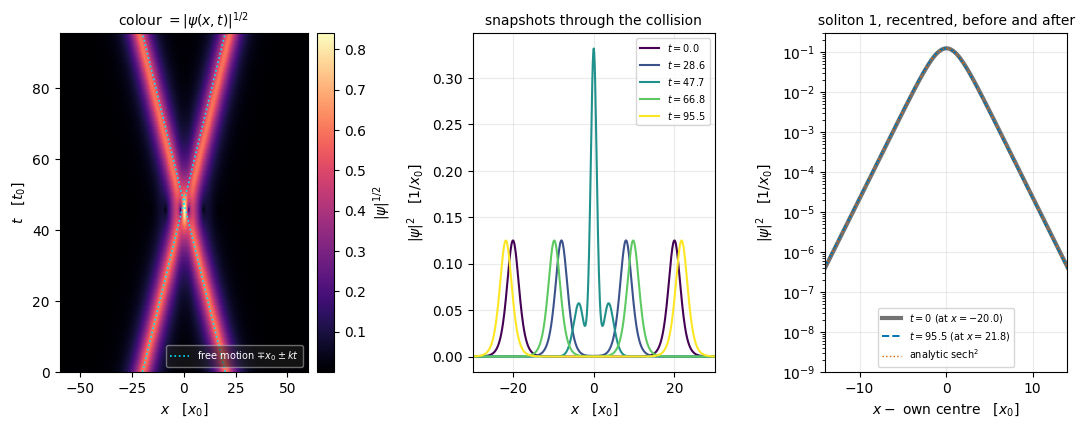

In [8]:
# ==============================================================================
# FIGURE: space-time map of the collision, with the free-motion lines drawn on top
# ==============================================================================
fig = plt.figure(figsize=(13.0, 4.4))
gs = fig.add_gridspec(1, 3, width_ratios=[1.25, 1, 1], wspace=0.42)

ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(np.abs(fr_main) ** 0.5, origin="lower", aspect="auto", cmap="magma",
               extent=[-L / 2, L / 2, 0, T_MAIN], interpolation="nearest")
ax.plot(-X0 + K_MAIN * t_main, t_main, ":", color="#00e5ff", lw=1.2, label=r"free motion $\mp x_0\pm kt$")
ax.plot(X0 - K_MAIN * t_main, t_main, ":", color="#00e5ff", lw=1.2)
ax.set_xlim(-L / 2, L / 2), ax.set_xlabel(r"$x$   [$x_0$]"), ax.set_ylabel(r"$t$   [$t_0$]")
ax.set_title(r"colour $=|\psi(x,t)|^{1/2}$", fontsize=10)
ax.legend(fontsize=7, loc="lower right", labelcolor="w", facecolor="0.15", framealpha=0.5)
fig.colorbar(im, ax=ax, pad=0.03, label=r"$|\psi|^{1/2}$")

ax = fig.add_subplot(gs[0, 1])
for j, idx in enumerate([0, 60, 100, 140, 200]):
    ax.plot(x, np.abs(fr_main[idx]) ** 2, lw=1.5, color=plt.get_cmap("viridis")(j / 4),
            label=rf"$t={t_main[idx]:.1f}$")
ax.set_xlim(-30, 30), ax.set_xlabel(r"$x$   [$x_0$]"), ax.set_ylabel(r"$|\psi|^2$   [$1/x_0$]")
ax.set_title("snapshots through the collision", fontsize=10)
ax.grid(alpha=0.25), ax.legend(fontsize=7)

ax = fig.add_subplot(gs[0, 2])
# soliton 1 starts on the left (x < 0) and ends on the right (x > 0); recentre each on its own peak
i_before = int(np.argmax(np.abs(fr_main[0]) ** 2 * (x < 0)))
i_after = int(np.argmax(np.abs(fr_main[-1]) ** 2 * (x > 0)))
ax.semilogy(x - x[i_before], np.abs(fr_main[0]) ** 2 + 1e-300, color=C_GREY, lw=3.0,
            label=rf"$t=0$ (at $x={x[i_before]:.1f}$)")
ax.semilogy(x - x[i_after], np.abs(fr_main[-1]) ** 2 + 1e-300, color=C_NUM, lw=1.4, ls="--",
            label=rf"$t={T_MAIN:.1f}$ (at $x={x[i_after]:.1f}$)")
ax.semilogy(x, np.abs(soliton_exact(x, 0.0, G, n=N_1)) ** 2, color=C_ANA, lw=1.0, ls=":",
            label=r"analytic $\mathrm{sech}^2$")
ax.set_xlim(-14, 14), ax.set_ylim(1e-9, 0.3)
ax.set_xlabel(r"$x - $ own centre   [$x_0$]"), ax.set_ylabel(r"$|\psi|^2$   [$1/x_0$]")
ax.set_title("soliton 1, recentred, before and after", fontsize=10)
ax.grid(alpha=0.25), ax.legend(fontsize=7, loc="lower center")
plt.show()

Two ridges enter, cross in a short burst of interference fringes, and two ridges leave with the same
brightness and the same slopes. The cyan dotted lines are free motion from the initial positions; after the
crossing the ridges run *outside* them, which is the position shift that Section 5 measures. The middle panel
follows the density through the crossing: at $t=47.7$ the two lumps have merged into one peak of $0.33$,
two and a half times either of them, and by $t=66.8$ they are two again. The right panel takes soliton 1
before the collision (at $x=-20$) and after it (at $x=+21.8$), recentres each on its own peak, and plots both
on a logarithmic scale together with the analytic $\mathrm{sech}^{2}$ of Eq. (2); the three curves
coincide over seven decades of density.

### 4.2 Measuring the two solitons separately

Everything quantitative in this notebook needs the *position* and the *norm* of each soliton while both are on
the same grid. The estimator is a windowed centroid: take a window of half-width $w$ around a guess, compute
the density-weighted mean of the (wrapped) distance from the guess, then move the window to that mean and
repeat. Iterating matters. A window centred on a point that is offset from the true centre by $\delta$ cuts
more of the soliton tail on one side than on the other and therefore reports a centre biased *towards the
guess*; re-centring removes the bias, leaving only the exponentially small effect of truncating a symmetric
$\mathrm{sech}^{2}$, which is $\sim e^{-2\kappa w}$.

> **Common pitfall.** A fixed window around an *expected* trajectory is a trap: it biases exactly the quantity
> one wants to measure, the deviation from that trajectory, and biases it towards zero. With $w=5$ and no
> re-centring the shift measured below comes out $9\%$ too small; four re-centrings bring the error down to
> $2\times10^{-3}$, and the wider window $w = 12$ used below to $2\times10^{-5}$.

In [9]:
# ==============================================================================
# STEP 3: tracking several solitons in one field
# ==============================================================================
def wrapped(x, c, L):
    """Signed distance from c to each grid point, on the ring: values in [-L/2, L/2)."""
    return (x - c + 0.5 * L) % L - 0.5 * L


def soliton_centre(psi, x, L, x_guess, half_width, n_iter=4):
    """Centre of the lump nearest x_guess, by an ITERATED windowed centroid.

    MATH
        c <- c + sum_{|x_j - c| < w} d_j |psi_j|^2 / sum_{|x_j - c| < w} |psi_j|^2,   d_j = wrapped(x_j, c)
    IMPLEMENTATION
        Re-centring the window after each pass removes the leading bias; what is left is the truncation of
        a symmetric sech^2 outside |d| < w, i.e. a relative error ~ exp(-2 kappa w).
    """
    c = float(x_guess)
    w2 = np.abs(psi) ** 2
    for _ in range(n_iter):
        d = wrapped(x, c, L)
        m = np.abs(d) < half_width
        c = c + float(np.sum(d[m] * w2[m]) / np.sum(w2[m]))
    return c


def window_norm(psi, x, dx, L, c, half_width):
    """dx sum |psi|^2 over the window |wrapped(x, c)| < half_width."""
    m = np.abs(wrapped(x, c, L)) < half_width
    return float(dx * np.sum(np.abs(psi[m]) ** 2))


def track_pair(frames, t, x, dx, L, x_guess_1, x_guess_2, half_width):
    """Centres of the two solitons in every frame, each seeded by its own free-motion guess.

    ARGUMENTS
        x_guess_1, x_guess_2 : (n_frames,) arrays, the free trajectories used only as seeds
    RETURNS
        (c_1, c_2) arrays of shape (n_frames,)
    """
    c1 = np.array([soliton_centre(p, x, L, gg, half_width) for p, gg in zip(frames, x_guess_1)])
    c2 = np.array([soliton_centre(p, x, L, gg, half_width) for p, gg in zip(frames, x_guess_2)])
    return c1, c2


HALF_WIDTH = 12.0            # window half-width: 6 soliton widths, truncation exp(-2 kappa w) = exp(-12)
print(f"tracking window: w = {HALF_WIDTH:g} = {HALF_WIDTH * KAP_1:g} soliton widths; "
      f"truncated norm per soliton = {N_1 * (1 - np.tanh(KAP_1 * HALF_WIDTH)):.3e}")

tracking window: w = 12 = 6 soliton widths; truncated norm per soliton = 6.144e-06


### 4.3 Elasticity of the collision: four measurements

"Elastic" is a claim with four parts, and each needs its own number.

1. **Norm.** The norm inside each window after the collision must equal what it was before. The floor of this
   test is the analytic $\mathrm{sech}^{2}$ tail outside the window,
   $N\left[1-\tanh(\kappa w)\right] = 6.1\times10^{-6}$ per soliton for $w=12$.
2. **Radiation.** The norm that is in *neither* window must be at that same floor; anything above it was
   radiated.
3. **Shape.** The outgoing profile must lie on the analytic $\mathrm{sech}$ of Eq. (2) with the *same*
   $\kappa$, not a fitted one.
4. **Velocity.** The slope of the outgoing trajectory must equal the incoming $k$.

In [10]:
# ==============================================================================
# CHECKPOINT 3: the four faces of elasticity, measured on the main run
# ==============================================================================
guess_L = -X0 + K_MAIN * t_main                       # free motion, used only to seed the windows
guess_R = +X0 - K_MAIN * t_main
cL, cR = track_pair(fr_main, t_main, x, dx, L, guess_L, guess_R, HALF_WIDTH)

nL = np.array([window_norm(p, x, dx, L, c, HALF_WIDTH) for p, c in zip(fr_main, cL)])
nR = np.array([window_norm(p, x, dx, L, c, HALF_WIDTH) for p, c in zip(fr_main, cR)])
tail_floor = N_1 * (1 - np.tanh(KAP_1 * HALF_WIDTH))

# radiation: norm outside BOTH windows, in the last frame
out_mask = (np.abs(wrapped(x, cL[-1], L)) >= HALF_WIDTH) & (np.abs(wrapped(x, cR[-1], L)) >= HALF_WIDTH)
radiation = float(dx * np.sum(np.abs(fr_main[-1][out_mask]) ** 2))

# shape: compare |psi| with the ANALYTIC sech of the same kappa, centred on the measured centre
ref_profile = np.abs(soliton_exact(x, 0.0, G, x_c=cL[-1], n=N_1))
in_win = np.abs(wrapped(x, cL[-1], L)) < HALF_WIDTH
shape_err = float(np.max(np.abs(np.abs(fr_main[-1][in_win]) - ref_profile[in_win])) / np.max(ref_profile))

# velocity: slope of the outgoing trajectory
late = t_main > 0.8 * T_MAIN
v_out = float(np.polyfit(t_main[late], cL[late], 1)[0])

print(f"1. norm in the left window : before {nL[0]:.8f}   after {nL[-1]:.8f}   "
      f"change {nL[-1] - nL[0]:+.2e}")
print(f"   norm in the right window: before {nR[0]:.8f}   after {nR[-1]:.8f}   "
      f"change {nR[-1] - nR[0]:+.2e}")
print(f"   analytic sech^2 tail outside the window: {tail_floor:.3e}  (this is the floor of the test)")
print(f"2. norm outside both windows at the end : {radiation:.3e}   floor 2 x tail = {2 * tail_floor:.3e}")
print(f"3. max | |psi| - analytic sech | / peak  : {shape_err:.3e}")
print(f"4. outgoing velocity {v_out:.10f}  vs incoming k = {K_MAIN:.10f}  "
      f"(relative {v_out / K_MAIN - 1:+.2e})")
print(f"   peak density after the collision: {float(np.max(np.abs(fr_main[-1]) ** 2)):.8f}   "
      f"analytic kappa^2/g = {KAP_1 ** 2 / G:.8f}")
assert abs(nL[-1] - nL[0]) < 1e-5 and abs(nR[-1] - nR[0]) < 1e-5
assert radiation < 3 * tail_floor
assert shape_err < 1e-4
assert abs(v_out / K_MAIN - 1) < 1e-4
print("\nCHECKPOINT 3 passed: nothing about either soliton changed except where it is.")

1. norm in the left window : before 0.49999392   after 0.49999393   change +4.89e-09
   norm in the right window: before 0.49999392   after 0.49999393   change +4.89e-09
   analytic sech^2 tail outside the window: 6.144e-06  (this is the floor of the test)
2. norm outside both windows at the end : 1.214e-05   floor 2 x tail = 1.229e-05
3. max | |psi| - analytic sech | / peak  : 1.034e-06
4. outgoing velocity 0.4188784177  vs incoming k = 0.4188790205  (relative -1.44e-06)
   peak density after the collision: 0.12497982   analytic kappa^2/g = 0.12500000

CHECKPOINT 3 passed: nothing about either soliton changed except where it is.


Every one of the four comes out at the floor of its own test.

* The norm in each window changes by $5\times10^{-9}$ over the collision.
* The norm that is in neither window is $1.214\times10^{-5}$, and the analytic $\mathrm{sech}^{2}$ tails of
  two solitons truncated at $w=12$ account for $1.229\times10^{-5}$ of that on their own. The radiated norm
  is therefore **below what this measurement can see**, one part in $10^{5}$.
* The outgoing profile agrees with the analytic $\mathrm{sech}$ — not a fit, the formula of Eq. (2) with the
  same $\kappa = 0.5$ — to $1\times10^{-6}$ of the peak amplitude.
* The outgoing velocity equals the incoming one to $1.4\times10^{-6}$ in relative terms, and the sampled peak
  density is $0.12498$ against $\kappa^{2}/g = 0.125$.

Each of the four has a blind spot. Tests 1 and 2 cannot see anything that stays
inside a window; test 3 compares $\vert\psi\vert$, so a component in *quadrature* with the soliton affects it
only at second order; test 4 measures a slope, not a shape. Together they are much stronger than any one of
them. A component in phase with the soliton is bounded by test 3 at $10^{-6}$ of the peak amplitude
$\kappa/\sqrt g$, i.e. at $10^{-11}$ of the norm once it is spread over the window. A quadrature component
large enough to hide from test 3 would have to stay inside the window for the whole run, and radiation of
wave number $q$ travels at group velocity $q$, so it only does that for $\vert q-k\vert$ below the window
half-width divided by the time left after the collision, about $12/50 = 0.24$. Radiation is produced over a
band much wider than that, and none of it shows up in test 2.

The remaining question is what *did* change.

## 5. The position shift and the phase shift

### 5.1 The asymptotic data of a collision

Long before and long after the collision each soliton moves freely, so its centre is a straight line of slope
$k_j$. The collision cannot change the slope — that is measurement 4 above — but it can change the intercept:

$$ x_j(t) \;\xrightarrow[t\to-\infty]{}\; x_j^{-} + k_jt , \qquad
   x_j(t) \;\xrightarrow[t\to+\infty]{}\; x_j^{-} + \Delta x_j + k_jt , \tag{9} $$

and likewise the internal phase of the soliton, which winds at the fixed rate $-(k_j^{2}/2+\mu_j)$ before and
after but may jump by $\Delta\theta_j$ in between. The two numbers $\Delta x_j$ and $\Delta\theta_j$ are the
entire content of the collision.

Extracting them is a finite-time version of an asymptotic statement: fit a straight line to the first $20\%$
of the trajectory and another to the last $20\%$, and subtract the intercepts. The windows must avoid the
overlap, and the fit is only as good as the assumption that the trajectory is already straight there, which
by Eq. (6) is true to $e^{-\kappa d}$.

### 5.2 The inverse-scattering prediction

Zakharov and Shabat (Sov. Phys. JETP **34**, 62 (1972)) showed that Eq. (1) is solved by inverse scattering:
the initial condition is mapped to the spectral data of an auxiliary linear problem, the spectral data evolve
trivially, and the map is inverted. Each soliton corresponds to one discrete eigenvalue
$\zeta_j = \xi_j + i\eta_j$ of that problem; the eigenvalues are constants of the motion, which is *why*
amplitudes and velocities cannot change in a collision. What a collision does change is the norming constant
attached to each eigenvalue, and the change is a pure translation plus a phase. For two solitons the standard
result is usually written

$$ \Delta x_1 \;=\; \frac{1}{2\eta_1}\,
   \ln\frac{\vert\zeta_1-\zeta_2^{*}\vert^{2}}{\vert\zeta_1-\zeta_2\vert^{2}} , \tag{10} $$

The logarithm is of a number larger than one, because $\vert\zeta_1-\zeta_2^{*}\vert$ has $\eta_1+\eta_2$
where $\vert\zeta_1-\zeta_2\vert$ has $\eta_1-\eta_2$; the right-hand side of Eq. (10) is therefore the
*magnitude* of the shift, and its sign is the sign of the velocity of soliton 1 relative to soliton 2. In the
variables of the scattering problem the envelope of soliton $j$ travels at $-4\xi_j$ (see the one-soliton
solution below), so that rule reads $\mathrm{sign}(\Delta x_1) = \mathrm{sign}(\xi_2-\xi_1)$; $\Delta x_2$ is
obtained by exchanging the labels.

Equation (10) is stated in the conventions of the scattering problem, not in ours, and the conversion is where
such formulas are usually got wrong. The dictionary is fixed by matching the one-soliton solution. Writing
$q = \sqrt g\,\psi$ turns Eq. (1) into $i q_t + \tfrac12 q_{xx} + \vert q\vert^{2}q = 0$, and rescaling the
time as $T = t/2$ turns *that* into the standard form $i q_T + q_{xx} + 2\vert q\vert^{2}q = 0$ whose
one-soliton solution is

$$ q \;=\; 2\eta\,\mathrm{sech}\!\left[2\eta(x-x_c+4\xi T)\right]\,
   e^{-2i\xi x - 4i(\xi^{2}-\eta^{2})T} . $$

Comparing amplitudes, $2\eta = \sqrt g\cdot\kappa_j/\sqrt g = \kappa_j$, so $\eta_j = \kappa_j/2$. Comparing
velocities, the envelope moves at $dx/dT = -4\xi$ in the standard variables and at $dx/dt = k_j$ in ours, and
$dx/dT = 2\,dx/dt$, so $-4\xi_j = 2k_j$ and $\xi_j = -k_j/2$. The dictionary is now over-determined, and the
phase is the check: $e^{-2i\xi x} = e^{ik_jx}$, and
$-4i(\xi^{2}-\eta^{2})T = -i\left(\tfrac{k_j^{2}}{2}-\tfrac{\kappa_j^{2}}{2}\right)t
= -i\left(\tfrac{k_j^{2}}{2}+\mu_j\right)t$ because $\mu_j = -\kappa_j^{2}/2$ — exactly the phase of Eq. (3),
with nothing left over. With that dictionary,

$$ \vert\zeta_1-\zeta_2\vert^{2} = \frac{(k_1-k_2)^{2} + (\kappa_1-\kappa_2)^{2}}{4} , \qquad
   \vert\zeta_1-\zeta_2^{*}\vert^{2} = \frac{(k_1-k_2)^{2} + (\kappa_1+\kappa_2)^{2}}{4} , $$

the factors of $4$ cancel inside the logarithm, $1/(2\eta_1) = 1/\kappa_1$, and Eq. (10) becomes, with
$\Delta k \equiv k_1-k_2$,

$$ \boxed{\;\Delta x_1 \;=\; \frac{1}{\kappa_1}\,
   \ln\frac{\Delta k^{2} + (\kappa_1+\kappa_2)^{2}}{\Delta k^{2} + (\kappa_1-\kappa_2)^{2}}\;} ,
   \qquad \Delta x_2 \;=\; -\frac{\kappa_1}{\kappa_2}\,\Delta x_1 , \tag{11} $$

for $k_1 > k_2$, i.e. for soliton 1 moving to the right relative to soliton 2. Three things to read off
Eq. (11).

* The logarithm is of a number **greater than one**, so $\Delta x_1 > 0$: the right-moving soliton emerges
  *ahead* of where free motion would have put it. That is the signature of attraction. The two solitons pull
  each other together on approach, which speeds each of them up, and pull each other back on separation, which
  slows them down again; the two effects do not cancel, and the residue is a forward displacement.
* For equal solitons, $\kappa_1=\kappa_2=\kappa$ and $\Delta k = 2k$:

$$ \Delta x \;=\; \frac{1}{\kappa}\ln\!\left(1+\frac{\kappa^{2}}{k^{2}}\right) , \tag{12} $$

  which behaves as $\kappa/k^{2}$ for fast collisions (the solitons barely have time to pull on each other)
  and grows logarithmically, $\approx (2/\kappa)\ln(\kappa/k)$, for slow ones.
* The same calculation gives a phase jump. For equal solitons it is

$$ \Delta\theta \;=\; 2\arctan\frac{2\kappa}{\Delta k} \;=\; 2\arctan\frac{\kappa}{k}
   \qquad (\mathrm{mod}\ 2\pi) , \tag{13} $$

  and for unequal ones
  $\Delta\theta_1 = 2\left[\arctan\frac{\kappa_1+\kappa_2}{\Delta k}-\arctan\frac{\kappa_1-\kappa_2}{\Delta k}\right]$.

Equations (11)-(13) are quoted from inverse-scattering theory; deriving them means constructing the
two-soliton solution and taking its asymptotics. What is done here is the conversion of conventions above,
followed by a numerical test that would expose any algebraic slip in it.

### 5.3 A sweep over the relative velocity with `vmap`

Ten collisions differing only in $k$. Each needs its own total time $T = 2x_0/k$, so each needs its own step
size if they are all to take the same number of steps — and the number of steps is exactly the quantity that
`lax.scan` needs at compile time, while the step size is an ordinary traced number. So the sweep is run as one
compiled program vectorised over *(initial state, time step)*.

> **JAX practice.** `jax.vmap(f)` turns a function written for one input into a function that applies it to a
> whole stacked batch, generating vectorised code rather than a Python loop — but every array shape and every
> loop length inside must be the same across the batch, which is why the *step size* is batched here and the
> *step count* is not. See [01 — JAX](01_jax_from_scratch.ipynb).

In [11]:
# ==============================================================================
# THE VELOCITY SWEEP: 10 collisions as one vmapped, jitted program
# ==============================================================================
M_LIST = np.array([4, 5, 6, 8, 10, 12, 16, 20, 24, 32])      # k = 2 pi m / L, commensurate with the ring
K_LIST = 2.0 * np.pi * M_LIST / L
T_LIST = 2.0 * X0 / K_LIST                                   # each run ends as far apart as it started
NFR_SW, NIN_SW = 100, 40                                     # frames, and inner steps per frame
DT_LIST = (T_LIST / NFR_SW) / NIN_SW                         # one step size per velocity

psi0_sweep = np.stack([two_solitons(x, X0, G, N_1, N_2, kk, -kk, 0.0) for kk in K_LIST])

sweep_run = jax.jit(jax.vmap(lambda p, dtv: split_step_frames(p, k_j, G, V_ZERO, dtv, NIN_SW, NFR_SW)))

t_wall = time.time()
FR_SWEEP = np.asarray(sweep_run(jnp.asarray(psi0_sweep), jnp.asarray(DT_LIST)))
print(f"{len(K_LIST)} collisions x {NIN_SW * NFR_SW} steps, vmapped (compile + run): "
      f"{time.time() - t_wall:.2f} s   -> array {FR_SWEEP.shape}")
print(f"step sizes from {DT_LIST.min():.5f} to {DT_LIST.max():.5f}")

10 collisions x 4000 steps, vmapped (compile + run): 1.53 s   -> array (10, 101, 1024)
step sizes from 0.00597 to 0.04775


In [12]:
# ==============================================================================
# CHECKPOINT 4: measured position shift vs Eq. (11), over a factor 8 in velocity
# ==============================================================================
def shift_analytic(kap_1, kap_2, dk):
    """Position shift of soliton 1 -- Eq. (11)."""
    return np.log((dk ** 2 + (kap_1 + kap_2) ** 2) / (dk ** 2 + (kap_1 - kap_2) ** 2)) / kap_1


def asymptote_shift(t, centres, frac=0.2):
    """Intercept(after) - intercept(before) from straight-line fits to the first and last `frac` of a run."""
    early, late = t < frac * t[-1], t > (1 - frac) * t[-1]
    c_e = np.polyfit(t[early], centres[early], 1)
    c_l = np.polyfit(t[late], centres[late], 1)
    return c_l[1] - c_e[1], c_l[0], c_e[0]


rows_v = []
print(f"{'k':>9s} {'2k':>8s} {'dt':>8s} {'dx measured':>13s} {'Eq. (11)':>12s} {'rel. diff':>11s} "
      f"{'v_out/k-1':>11s} {'radiation':>11s}")
for j, kk in enumerate(K_LIST):
    tt = np.arange(NFR_SW + 1) * (T_LIST[j] / NFR_SW)
    frs = FR_SWEEP[j]
    cl_, cr_ = track_pair(frs, tt, x, dx, L, -X0 + kk * tt, X0 - kk * tt, HALF_WIDTH)
    d_meas, v_l, _ = asymptote_shift(tt, cl_)
    d_pred = shift_analytic(KAP_1, KAP_2, 2 * kk)
    out_m = (np.abs(wrapped(x, cl_[-1], L)) >= HALF_WIDTH) & (np.abs(wrapped(x, cr_[-1], L)) >= HALF_WIDTH)
    rad = float(dx * np.sum(np.abs(frs[-1][out_m]) ** 2))
    rows_v.append((kk, d_meas, d_pred, rad))
    print(f"{kk:9.5f} {2 * kk:8.4f} {DT_LIST[j]:8.5f} {d_meas:13.6f} {d_pred:12.6f} "
          f"{(d_meas - d_pred) / d_pred:11.2e} {v_l / kk - 1:11.2e} {rad:11.3e}")

rows_v = np.array(rows_v)
rel = np.abs(rows_v[:, 1] - rows_v[:, 2]) / rows_v[:, 2]
print(f"\nlargest relative deviation from Eq. (11) over the sweep: {rel.max():.2e}")
print(f"analytic tail floor for the radiation column: {2 * tail_floor:.3e}")
assert rel.max() < 1e-3, "the measured shift must follow Eq. (11)"
print("CHECKPOINT 4 passed: Eq. (11), including the conversion of conventions, is confirmed.")

        k       2k       dt   dx measured     Eq. (11)   rel. diff   v_out/k-1   radiation
  0.20944   0.4189  0.04775      3.804000     3.804011   -2.82e-06   -6.11e-07   1.234e-05
  0.26180   0.5236  0.03820      3.072674     3.072686   -3.88e-06   -4.65e-07   1.202e-05
  0.31416   0.6283  0.03183      2.524320     2.524311    3.23e-06   -9.25e-07   1.235e-05
  0.41888   0.8378  0.02387      1.771553     1.771522    1.75e-05   -1.29e-06   1.207e-05
  0.52360   1.0472  0.01910      1.296221     1.296185    2.80e-05   -1.27e-06   1.208e-05
  0.62832   1.2566  0.01592      0.981189     0.981153    3.70e-05   -1.18e-06   1.214e-05
  0.83776   1.6755  0.01194      0.609410     0.609384    4.25e-05   -7.73e-07   1.217e-05
  1.04720   2.0944  0.00955      0.410736     0.410729    1.70e-05   -2.15e-07   1.215e-05
  1.25664   2.5133  0.00796      0.293923     0.293932   -2.82e-05    2.28e-07   1.214e-05
  1.67552   3.3510  0.00597      0.170583     0.170615   -1.84e-04    8.97e-07   1.214e-05

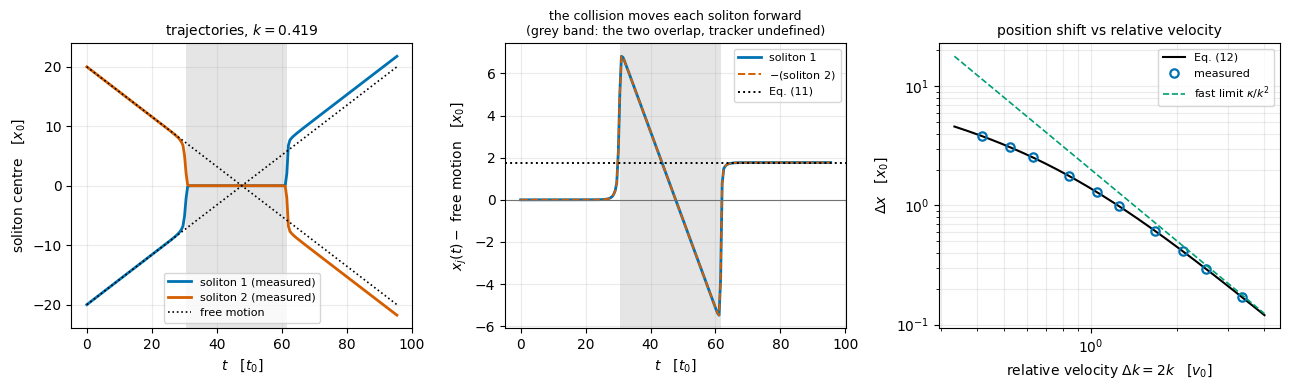

In [13]:
# ==============================================================================
# FIGURE: trajectories, and the shift as a function of the relative velocity
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.0))

# the two windows contain the same object while the solitons overlap, so the tracker is
# meaningless there; mark that interval instead of pretending the curve means something
t_overlap = (np.abs(cL - cR) < 4.0 / KAP_1)
span = (t_main[t_overlap].min(), t_main[t_overlap].max()) if t_overlap.any() else (0.0, 0.0)

# --- left: the two trajectories of the main run against free motion ---
for a_ in axes[:2]:
    a_.axvspan(*span, color=C_GREY, alpha=0.18, lw=0)
axes[0].plot(t_main, cL, color=C_NUM, lw=2.0, label=r"soliton 1 (measured)")
axes[0].plot(t_main, cR, color=C_ANA, lw=2.0, label=r"soliton 2 (measured)")
axes[0].plot(t_main, guess_L, "k:", lw=1.2, label=r"free motion")
axes[0].plot(t_main, guess_R, "k:", lw=1.2)
axes[0].set_xlabel(r"$t$   [$t_0$]"), axes[0].set_ylabel(r"soliton centre   [$x_0$]")
axes[0].set_title(rf"trajectories, $k={K_MAIN:.3f}$", fontsize=10)
axes[0].grid(alpha=0.25), axes[0].legend(fontsize=8)

# --- middle: the deviation from free motion, which is the shift ---
axes[1].plot(t_main, cL - guess_L, color=C_NUM, lw=2.0, label=r"soliton 1")
axes[1].plot(t_main, -(cR - guess_R), color=C_ANA, lw=1.4, ls="--", label=r"$-$(soliton 2)")
axes[1].axhline(shift_analytic(KAP_1, KAP_2, 2 * K_MAIN), color="k", ls=":", lw=1.4,
                label=r"Eq. (11)")
axes[1].axhline(0.0, color=C_GREY, lw=0.8)
axes[1].set_xlabel(r"$t$   [$t_0$]"), axes[1].set_ylabel(r"$x_j(t) - $ free motion   [$x_0$]")
axes[1].set_title("the collision moves each soliton forward\n(grey band: the two overlap, tracker undefined)",
                  fontsize=9)
axes[1].grid(alpha=0.25), axes[1].legend(fontsize=8)

# --- right: shift vs relative velocity ---
k_fine = np.linspace(0.8 * K_LIST.min(), 1.2 * K_LIST.max(), 300)
axes[2].loglog(2 * k_fine, shift_analytic(KAP_1, KAP_2, 2 * k_fine), color="k", lw=1.5,
               label=r"Eq. (12)")
axes[2].loglog(2 * rows_v[:, 0], rows_v[:, 1], "o", ms=6, color=C_NUM, mfc="none", mew=1.6,
               label="measured")
axes[2].loglog(2 * k_fine, KAP_1 / k_fine ** 2, "--", color=C_THIRD, lw=1.2,
               label=r"fast limit $\kappa/k^{2}$")
axes[2].set_xlabel(r"relative velocity $\Delta k = 2k$   [$v_0$]")
axes[2].set_ylabel(r"$\Delta x$   [$x_0$]")
axes[2].set_title("position shift vs relative velocity", fontsize=10)
axes[2].grid(alpha=0.25, which="both"), axes[2].legend(fontsize=8)
fig.tight_layout()
plt.show()

The left panel shows the two centres tracking free motion, bending towards each other as they approach, and
leaving on lines parallel to the dotted ones but displaced outwards. Inside the grey band the two tracking
windows contain the same object and the "centre of soliton 1" is not a defined quantity — the curves there
are an artefact of the estimator, and only the two plateaus on either side mean anything. The
middle panel subtracts free motion: a curve flat at zero, a meaningless excursion through the overlap, and a
new plateau equal to the dotted prediction of Eq. (11). The two solitons move in opposite directions and
their deviations are exact mirror images, which is the centre-of-mass sum rule of Section 8 in the symmetric
case.

The right panel is the test over a factor of eight in velocity. Measured points lie on the curve of Eq. (12)
over more than a decade in $\Delta x$, and the table prints the relative deviations: they run from
$3\times10^{-6}$ to $2\times10^{-4}$, i.e. at most $4\times10^{-5}$ in absolute terms. That is far above the
$e^{-\kappa d} = 2\times10^{-9}$ floor of Section 2.6, and it is the level at which the measured shift also
moves when $N_x$, $\Delta t$ or $x_0$ is changed (Section 10.2): the resolution of the tracking and of the
asymptote fits. The green dashed line is the fast-collision asymptote $\kappa/k^{2}$, which the data
join from above.

The radiation column of the table stays at $1.2\times10^{-5}$ for every velocity, equal to the analytic tail
floor: the collisions are elastic at the slowest velocity tried ($\Delta k = 0.42$, where the solitons take
so long to pass through each other that the shift is $3.8$ length units, nearly two widths) just as they are
at the fastest.

### 5.4 The phase shift

The internal phase of a free soliton advances as $\arg\psi(x_j(t),t) = k_jx_j(t) - (k_j^{2}/2+\mu_j)t +
\text{const}$, by Eq. (3). Subtracting that from the measured phase at the measured centre leaves a constant
before the collision and a different constant after it, and the difference is $\Delta\theta$ of Eq. (13).
Phases are defined modulo $2\pi$, and the unwrapped difference accumulates whole turns that carry no
information, so the comparison below is made modulo $2\pi$.

In [14]:
# ==============================================================================
# CHECKPOINT 5: the phase shift, Eq. (13)
# ==============================================================================
def soliton_phase(psi, x, L, c, k_0, mu, t):
    """arg(psi) at the soliton centre, minus the free-soliton phase there -- see Eq. (3)."""
    j = int(np.argmin(np.abs(wrapped(x, c, L))))
    return float(np.angle(psi[j]) - (k_0 * x[j] - (0.5 * k_0 ** 2 + mu) * t))


mu_1 = -0.5 * KAP_1 ** 2
print(f"{'k':>9s} {'dt':>8s} {'dtheta measured':>17s} {'Eq. (13)':>12s} {'difference':>12s}")
diff_by_j = {}
for j in (0, 2, 3, 5, 6, 8):
    kk = K_LIST[j]
    tt = np.arange(NFR_SW + 1) * (T_LIST[j] / NFR_SW)
    frs = FR_SWEEP[j]
    cl_, _ = track_pair(frs, tt, x, dx, L, -X0 + kk * tt, X0 - kk * tt, HALF_WIDTH)
    th = np.unwrap(np.array([soliton_phase(p, x, L, c, kk, mu_1, tv)
                             for p, c, tv in zip(frs, cl_, tt)]))
    dth, _, _ = asymptote_shift(tt, th)
    dth_pred = 2.0 * np.arctan(KAP_1 / kk)
    diff = (dth - dth_pred + np.pi) % (2 * np.pi) - np.pi          # compare modulo 2 pi
    diff_by_j[j] = diff
    print(f"{kk:9.5f} {DT_LIST[j]:8.5f} {dth:17.6f} {dth_pred:12.6f} {diff:12.2e}")
    assert abs(diff) < 5e-3, "the phase shift must follow Eq. (13)"

# the sweep gives every velocity the same number of steps, hence a different dt; repeat the
# slowest run with a four times smaller step to show that the residual is the splitting error
j_slow_chk = 0
T_chk = T_LIST[j_slow_chk]
fr_chk = np.asarray(split_step_frames(jnp.asarray(psi0_sweep[j_slow_chk]), k_j, G, V_ZERO,
                                      (T_chk / NFR_SW) / (4 * NIN_SW), 4 * NIN_SW, NFR_SW))
t_chk = np.arange(NFR_SW + 1) * (T_chk / NFR_SW)
c_chk, _ = track_pair(fr_chk, t_chk, x, dx, L,
                      -X0 + K_LIST[j_slow_chk] * t_chk, X0 - K_LIST[j_slow_chk] * t_chk, HALF_WIDTH)
th_chk = np.unwrap(np.array([soliton_phase(p, x, L, c, K_LIST[j_slow_chk], mu_1, tv)
                             for p, c, tv in zip(fr_chk, c_chk, t_chk)]))
dth_chk, _, _ = asymptote_shift(t_chk, th_chk)
diff_chk = (dth_chk - 2 * np.arctan(KAP_1 / K_LIST[j_slow_chk]) + np.pi) % (2 * np.pi) - np.pi
print(f"\nsame run at dt = {DT_LIST[j_slow_chk] / 4:.5f} (four times smaller): "
      f"difference {diff_chk:.2e}, i.e. {abs(diff_by_j[j_slow_chk] / diff_chk):.1f} times smaller "
      f"(O(dt^2) predicts 16)")
print("CHECKPOINT 5 passed: the phase jump is 2 arctan(kappa/k), modulo 2 pi.")

        k       dt   dtheta measured     Eq. (13)   difference
  0.20944  0.04775          2.347118     2.348243    -1.13e-03
  0.31416  0.03183          2.019608     2.019628    -2.08e-05
  0.41888  0.02387          1.746667     1.746905    -2.38e-04
  0.62832  0.01592          1.344226     1.344318    -9.22e-05
  0.83776  0.01194          1.076149     1.076172    -2.34e-05
  1.25664  0.00796          0.757352     0.757368    -1.58e-05



same run at dt = 0.01194 (four times smaller): difference -6.68e-05, i.e. 16.8 times smaller (O(dt^2) predicts 16)
CHECKPOINT 5 passed: the phase jump is 2 arctan(kappa/k), modulo 2 pi.


The measured jumps reproduce $2\arctan(\kappa/k)$ with residuals between $1.6\times10^{-5}$ and
$1.1\times10^{-3}$ radians. The largest residual belongs to the slowest velocity, which is also the one the
sweep gives the largest time step: every run in the sweep takes the same number of steps, so
$\Delta t = T/4000$ grows with $T = 2x_0/k$. Repeating that run with four times as many steps shrinks the
residual by a factor of $16.8$, the $O(\Delta t^{2})$ of the Strang splitting. The comparison is made modulo
$2\pi$ because an unwrapped phase accumulates whole turns during a run whose duration differs from velocity
to velocity, and those turns carry no information; for the unequal solitons of Section 8 they are actually
there.

Position and phase together are a single complex statement. With $\Delta k = 2k$ for equal solitons,

$$ \frac{\kappa}{2}\,\Delta x \;+\; \frac{i}{2}\,\Delta\theta
   \;=\; \frac{1}{2}\ln\!\left(1+\frac{\kappa^{2}}{k^{2}}\right) + i\arctan\frac{\kappa}{k}
   \;=\; \ln\!\left(1 + \frac{i\kappa}{k}\right) , \tag{14} $$

one complex logarithm: the displacement is $2/\kappa$ times the logarithm of the modulus of $1+i\kappa/k$,
and the phase jump is twice its argument — the same
structure as Eq. (10), where the shift is the logarithm of a *ratio of complex numbers* built from the two
scattering eigenvalues.

## 6. The relative phase

### 6.1 The overlap and the outcome

Section 2.3 showed that for a symmetric pair the relative phase at the collision is the $\Delta\phi$ put into
the initial state. It decides what the field looks like while the two solitons overlap, and the two extreme
cases are easy to state in advance.

* $\Delta\phi = 0$: the state is even, the two contributions add at $x=0$, and the density there should reach
  the constructive-interference value. Two amplitudes $A$ on top of each other give $(2A)^{2} = 4A^{2}$, i.e.
  four times the single-soliton peak density $\kappa^{2}/g$, or $0.5$ here.
* $\Delta\phi = \pi$: the state is odd, so $\psi(0,t)=0$ **exactly, for all $t$**, as Section 2.3 proved from
  parity. The two solitons never share a point; the density keeps a node between them and the collision looks
  like a bounce.

What $\Delta\phi$ cannot change, in the integrable equation, is the outcome. Inverse scattering says the
discrete eigenvalues $\zeta_j$ — hence the amplitudes, the widths and the velocities — are determined by the
initial condition and then frozen. For two well-separated solitons the eigenvalues are those of the
individual solitons up to $O(e^{-\kappa d})$, whatever the relative phase, because $\Delta\phi$ enters the
scattering data only through the norming constants, which set positions and phases. So the prediction is:
the final norms are equal to the initial ones, and even the position shift of Eq. (11) is independent of
$\Delta\phi$. Both are measured below.

In [15]:
# ==============================================================================
# THE PHASE SWEEP: 9 relative phases, one vmapped program (same T, same dt -- only psi(0) differs)
# ==============================================================================
D_PHI = np.linspace(0.0, np.pi, 9)
NFR_PH, NIN_PH = 200, 20
dt_ph = (T_MAIN / NFR_PH) / NIN_PH
t_ph = np.arange(NFR_PH + 1) * (T_MAIN / NFR_PH)

psi0_phase = np.stack([two_solitons(x, X0, G, N_1, N_2, K_MAIN, -K_MAIN, dp) for dp in D_PHI])
phase_run = jax.jit(jax.vmap(lambda p: split_step_frames(p, k_j, G, V_ZERO, dt_ph, NIN_PH, NFR_PH)))

t_wall = time.time()
FR_PHASE = np.asarray(phase_run(jnp.asarray(psi0_phase)))
print(f"{len(D_PHI)} relative phases x {NIN_PH * NFR_PH} steps, vmapped: {time.time() - t_wall:.2f} s"
      f"   -> array {FR_PHASE.shape}")

9 relative phases x 4000 steps, vmapped: 1.25 s   -> array (9, 201, 1024)


In [16]:
# ==============================================================================
# CHECKPOINT 6: what the phase changes (the picture) and what it does not (the outcome)
# ==============================================================================
i_coll = int(np.argmin(np.abs(t_ph - X0 / K_MAIN)))          # frame nearest the free collision time
d_pred_main = shift_analytic(KAP_1, KAP_2, 2 * K_MAIN)

print(f"{'dphi/pi':>8s} {'max density':>12s} {'at t':>8s} {'at x':>8s} {'rho(0,t_c)':>12s} {'N_left':>10s} "
      f"{'N_right':>10s} {'N_r - N_l':>11s} {'dx - Eq.(11)':>13s}")
rows_ph = []
for j, dp in enumerate(D_PHI):
    frs = FR_PHASE[j]
    dens = np.abs(frs) ** 2
    i_lo = max(0, i_coll - 8)
    near = dens[i_lo:i_coll + 9]
    i_max = np.unravel_index(int(np.argmax(near)), near.shape)
    t_max = t_ph[i_lo + i_max[0]]                      # when the density peak is actually reached
    cl_, cr_ = track_pair(frs, t_ph, x, dx, L, -X0 + K_MAIN * t_ph, X0 - K_MAIN * t_ph, HALF_WIDTH)
    nl_ = window_norm(frs[-1], x, dx, L, cl_[-1], HALF_WIDTH)
    nr_ = window_norm(frs[-1], x, dx, L, cr_[-1], HALF_WIDTH)
    d_meas, _, _ = asymptote_shift(t_ph, cl_)
    rows_ph.append((dp, float(near.max()), float(dens[i_coll, N_X // 2]), nl_, nr_, d_meas))
    print(f"{dp / np.pi:8.3f} {near.max():12.6f} {t_max:8.2f} {x[i_max[1]]:8.3f} "
          f"{dens[i_coll, N_X // 2]:12.3e} "
          f"{nl_:10.6f} {nr_:10.6f} {nr_ - nl_:11.2e} {d_meas - d_pred_main:13.2e}")

rows_ph = np.array(rows_ph)
print(f"\nin-phase peak density {rows_ph[0, 1]:.6f}  vs  4 x single-soliton peak = "
      f"{4 * KAP_1 ** 2 / G:.6f}   (ratio {rows_ph[0, 1] / (4 * KAP_1 ** 2 / G):.4f})")
print(f"out-of-phase density at x = 0 at the collision: {rows_ph[-1, 2]:.3e}   (parity forces it to vanish)")
print(f"largest norm transfer over the sweep : {np.max(np.abs(rows_ph[:, 4] - rows_ph[:, 3])):.2e}")
print(f"spread of the position shift         : {rows_ph[:, 5].max() - rows_ph[:, 5].min():.2e} "
      f"out of dx = {d_pred_main:.6f}  (relative "
      f"{(rows_ph[:, 5].max() - rows_ph[:, 5].min()) / d_pred_main:.1e})")

# the residual asymmetry above is largest at the same phase as the residual of the shift, which
# suggests the splitting error rather than physics: repeat the worst case with dt four times smaller
j_worst = int(np.argmax(np.abs(rows_ph[:, 4] - rows_ph[:, 3])))
fr_fine = np.asarray(split_step_frames(jnp.asarray(psi0_phase[j_worst]), k_j, G, V_ZERO,
                                       (T_MAIN / NFR_PH) / (4 * NIN_PH), 4 * NIN_PH, NFR_PH))
cl_f, cr_f = track_pair(fr_fine, t_ph, x, dx, L, -X0 + K_MAIN * t_ph, X0 - K_MAIN * t_ph, HALF_WIDTH)
transfer_fine = (window_norm(fr_fine[-1], x, dx, L, cr_f[-1], HALF_WIDTH)
                 - window_norm(fr_fine[-1], x, dx, L, cl_f[-1], HALF_WIDTH))
shift_fine, _, _ = asymptote_shift(t_ph, cl_f)
transfer_coarse = rows_ph[j_worst, 4] - rows_ph[j_worst, 3]
print(f"\nworst case, dphi = {D_PHI[j_worst] / np.pi:.3f} pi, with dt four times smaller "
      f"({(T_MAIN / NFR_PH) / (4 * NIN_PH):.5f}):")
print(f"   norm transfer  {transfer_coarse:.2e} -> {transfer_fine:.2e}  "
      f"(factor {abs(transfer_coarse / transfer_fine):.1f}; O(dt^2) predicts 16)")
print(f"   shift residual {rows_ph[j_worst, 5] - d_pred_main:.2e} -> {shift_fine - d_pred_main:.2e}")
assert rows_ph[-1, 2] < 1e-15, "an odd state must vanish at the origin"
assert np.max(np.abs(rows_ph[:, 4] - rows_ph[:, 3])) < 1e-4, "no norm transfer in the integrable equation"
assert abs(transfer_fine) < 0.2 * abs(transfer_coarse), "the residual transfer must vanish with dt"
assert (rows_ph[:, 5].max() - rows_ph[:, 5].min()) / d_pred_main < 1e-3
print("CHECKPOINT 6 passed: the phase rearranges the collision, not its outcome.")

 dphi/pi  max density     at t     at x   rho(0,t_c)     N_left    N_right   N_r - N_l  dx - Eq.(11)
   0.000     0.497778    45.84    0.000    3.317e-01   0.499994   0.499994    7.11e-13      4.02e-05
   0.125     0.488271    45.84    0.352    2.973e-01   0.499999   0.499989   -9.67e-06      2.22e-04
   0.250     0.467368    45.84    0.586    2.184e-01   0.500002   0.499986   -1.62e-05      3.42e-04
   0.375     0.433602    45.84    0.938    1.374e-01   0.500003   0.499985   -1.83e-05      3.76e-04
   0.500     0.396037    45.84    1.172    7.648e-02   0.500002   0.499986   -1.68e-05      3.37e-04


   0.625     0.355066    45.84    1.406    3.745e-02   0.500001   0.499987   -1.33e-05      2.57e-04
   0.750     0.314678    45.84    1.641    1.488e-02   0.499998   0.499989   -9.01e-06      1.61e-04
   0.875     0.276630    45.84    1.875    3.463e-03   0.499996   0.499992   -4.50e-06      6.50e-05
   1.000     0.241352    45.84    2.109    4.685e-20   0.499994   0.499994    3.07e-13     -2.42e-05

in-phase peak density 0.497778  vs  4 x single-soliton peak = 0.500000   (ratio 0.9956)
out-of-phase density at x = 0 at the collision: 4.685e-20   (parity forces it to vanish)
largest norm transfer over the sweep : 1.83e-05
spread of the position shift         : 4.00e-04 out of dx = 1.771522  (relative 2.3e-04)



worst case, dphi = 0.375 pi, with dt four times smaller (0.00597):
   norm transfer  -1.83e-05 -> -1.14e-06  (factor 16.0; O(dt^2) predicts 16)
   shift residual 3.76e-04 -> 4.84e-05
CHECKPOINT 6 passed: the phase rearranges the collision, not its outcome.


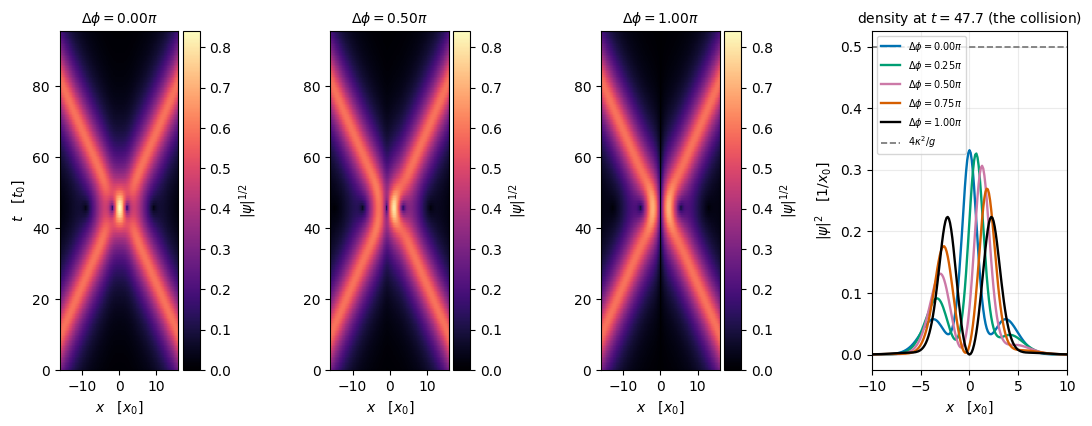

In [17]:
# ==============================================================================
# FIGURE: three space-time maps and the density at the moment of collision
# ==============================================================================
fig = plt.figure(figsize=(13.0, 4.4))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.35], wspace=0.8)

for panel, j in enumerate([0, 4, 8]):
    axn = fig.add_subplot(gs[0, panel])
    im = axn.imshow(np.abs(FR_PHASE[j]) ** 0.5, origin="lower", aspect="auto", cmap="magma",
                    extent=[-L / 2, L / 2, 0, T_MAIN], interpolation="nearest",
                    vmin=0.0, vmax=float(np.abs(FR_PHASE[0]).max() ** 0.5))
    axn.set_xlim(-16, 16)
    axn.set_xlabel(r"$x$   [$x_0$]")
    if panel == 0:
        axn.set_ylabel(r"$t$   [$t_0$]")
    axn.set_title(rf"$\Delta\phi = {D_PHI[j] / np.pi:.2f}\pi$", fontsize=10)
    fig.colorbar(im, ax=axn, pad=0.03, label=r"$|\psi|^{1/2}$")

axn = fig.add_subplot(gs[0, 3])
for j, col in zip([0, 2, 4, 6, 8], [C_NUM, C_THIRD, C_FOURTH, C_ANA, "k"]):
    axn.plot(x, np.abs(FR_PHASE[j][i_coll]) ** 2, lw=1.7, color=col,
             label=rf"$\Delta\phi={D_PHI[j] / np.pi:.2f}\pi$")
axn.axhline(4 * KAP_1 ** 2 / G, color=C_GREY, ls="--", lw=1.2, label=r"$4\kappa^2/g$")
axn.set_xlim(-10, 10), axn.set_xlabel(r"$x$   [$x_0$]"), axn.set_ylabel(r"$|\psi|^2$   [$1/x_0$]")
axn.set_title(rf"density at $t={t_ph[i_coll]:.1f}$ (the collision)", fontsize=10)
axn.grid(alpha=0.25), axn.legend(fontsize=7)
plt.show()

The three maps are the same collision with three relative phases. At $\Delta\phi=0$ the two ridges merge
into one bright spot; at $\Delta\phi=\pi/2$ the bright region is displaced to one side; at
$\Delta\phi=\pi$ there is a dark line straight down the middle of the crossing — the exact node, which no
amount of nonlinearity can close because parity forbids it. The three maps are otherwise identical, and in
particular the outgoing ridges are in the same place in all three.

The right panel makes the crossover quantitative. The peak density reached during the collision falls
monotonically from $0.4978$ at $\Delta\phi=0$ to $0.2414$ at $\Delta\phi=\pi$, and the in-phase value is
$0.9956$ of the naive constructive-interference estimate $4\kappa^{2}/g = 0.5$. The density *at the origin*
at the moment of collision falls from $0.332$ to $4.7\times10^{-20}$, which is zero to round-off. (The
curves drawn in the right panel are the frame nearest the *free* collision time $t_c = x_0/k = 47.7$, where
the in-phase peak is already down to $0.33$; the maximum $0.4978$ is reached at $t=45.8$, about two time
units earlier, because the solitons attract each other on approach and meet before free motion says they
should — the same $45.8$ that Section 10.3 measures. That is why the table quotes a maximum over frames and
the time at which it occurs.)

The two columns on the right of the table describe the outcome. The final norms of the two solitons
differ by at most $1.8\times10^{-5}$ at any relative phase, and the position shift varies by
$4.0\times10^{-4}$ out of $1.77$, i.e. by $2.3\times10^{-4}$ in relative terms, over the whole range of
$\Delta\phi$. Both residuals peak at the same intermediate phase, $\Delta\phi = 3\pi/8$, which is a hint
that they are one and the same numerical artefact — and repeating that run with a time step four times
smaller divides the norm transfer by $16.0$ and the shift residual by $7.8$. There is no norm transfer in the
integrable equation; what the table shows at $10^{-5}$ is the splitting error. In the integrable equation the
relative phase decides what one *sees* and changes nothing that survives.

> **Physics insight.** What the relative phase controls is the *density during the overlap*, which is a factor
> of two here and can be much more for slower collisions; and density is exactly what decides whether an
> attractive condensate collapses. Equation (1) has no collapse (00c, Section 6.2), so in it the density spike
> does nothing that survives the collision. A laboratory soliton is only *quasi*-one-dimensional: it keeps a
> transverse degree of freedom on which the spike can act, which is why a phase-resolved collision experiment
> such as that of Nguyen *et al.* (Nature Physics **10**, 918 (2014)) can see an outcome that Eq. (1) forbids.
> Section 9 adds a term that lets the spike do something here too.

## 7. Two solitons at rest: the interaction force

### 7.1 Where an exponential force comes from

Section 6 used fast collisions, in which the two solitons are close for a short time. The opposite limit is
two solitons *at rest* a distance $r$ apart. They are not in equilibrium: their tails overlap, and the overlap
has an energy.

The size of that energy follows from Eq. (5). The cross terms in the energy functional (8) are linear in each
profile's tail evaluated where the other soliton sits, so they scale as the product of the two tails,

$$ E_{\rm int}(r,\Delta\phi) \;\sim\; -\,C\,\kappa^{?}\;e^{-\kappa r}\cos\Delta\phi , \tag{15} $$

with the $\cos\Delta\phi$ because the cross terms carry the relative phase as
$\psi_1^{*}\psi_2 + \psi_2^{*}\psi_1 = 2\mathrm{Re}(\psi_1^{*}\psi_2)$ and both profiles are real up to that
phase. Differentiating, the force is also $\propto e^{-\kappa r}\cos\Delta\phi$: **exponential in the
separation, sinusoidal in the relative phase**, which is exactly what Gordon reported for optical solitons in
1983 (Opt. Lett. **8**, 596 (1983)) and what makes neighbouring pulses in a fibre bit stream attract or repel.

The rate of the exponential is not a fitted parameter: it is $\kappa$, the *amplitude* decay rate of the
soliton, because the interaction is linear in each tail amplitude and not in each tail density. The overall
constant and the power of $\kappa$ are left open in Eq. (15) — the dimensional argument fixes the power once
the constant is known. Section 7.2 measures the force first and derives the constant afterwards, in that
order, so that the derivation has something to be checked against.

### 7.2 Measuring the force

Prepare the pair at rest at separation $r_0$, track the separation $r(t)$, and fit a parabola
$r(t) = r_0 + \dot r_0 t + \tfrac12 a t^{2}$ over an early window. Since for $\Delta\phi\in\{0,\pi\}$ the
state has definite parity and the density stays symmetric, the two centres can be read off directly as the
density-weighted means over $x>0$ and $x<0$, with no window to choose. The overlapping tails bias that
estimate of the separation itself (constructive interference at the origin pulls it inwards in phase, the
node pushes it outwards out of phase), but the bias changes little over the fit window, so the fitted
acceleration is unaffected. The force law is therefore evaluated at the *prepared* separation $r_0$, at which
Eq. (4) places the two centres exactly. The same estimator is used for the scan over intermediate
$\Delta\phi$ below, where parity does not hold; there it measures the relative coordinate of a pair that is
itself drifting slowly, and the resulting bias is part of the residual quoted at the end of the section.

In [18]:
# ==============================================================================
# THE FORCE MEASUREMENT: pairs at rest, vmapped over separation and relative phase
# ==============================================================================
D_LIST = np.array([8.0, 10.0, 12.0, 14.0, 16.0, 18.0])
PHI_TWO = np.array([0.0, np.pi])
T_FORCE, NFR_F, NIN_F = 40.0, 80, 50
dt_force = (T_FORCE / NFR_F) / NIN_F
t_force = np.arange(NFR_F + 1) * (T_FORCE / NFR_F)

combo = [(d_, p_) for p_ in PHI_TWO for d_ in D_LIST]
psi0_force = np.stack([two_solitons(x, d_ / 2, G, N_1, N_2, 0.0, 0.0, p_) for d_, p_ in combo])
force_run = jax.jit(jax.vmap(lambda p: split_step_frames(p, k_j, G, V_ZERO, dt_force, NIN_F, NFR_F)))

t_wall = time.time()
FR_FORCE = np.asarray(force_run(jnp.asarray(psi0_force)))
print(f"{len(combo)} pairs at rest x {NIN_F * NFR_F} steps, vmapped: {time.time() - t_wall:.2f} s")


def separation(frames, x, L):
    """r(t) = <x>_{x>0} - <x>_{x<0} for a pair centred on the origin.

    CAVEAT
        The overlapping tails bias r (inwards in phase, outwards out of phase); the bias varies slowly,
        so the curvature of r(t), i.e. the acceleration, is unaffected.
    """
    out = []
    for p in frames:
        w = np.abs(p) ** 2
        out.append(float(np.sum(x[x > 0] * w[x > 0]) / np.sum(w[x > 0])
                         - np.sum(x[x < 0] * w[x < 0]) / np.sum(w[x < 0])))
    return np.array(out)


print(f"\n{'r_0 asked':>10s} {'dphi':>7s} {'r(0) meas':>11s} {'acceleration a':>16s} "
      f"{'-8 kappa^3 e^{-kappa r} cos':>28s} {'ratio':>8s}")
acc = {}
for idx, (d_, p_) in enumerate(combo):
    r_t = separation(FR_FORCE[idx], x, L)
    n_fit = NFR_F // 3
    a_meas = 2.0 * np.polyfit(t_force[:n_fit], r_t[:n_fit], 2)[0]
    a_pred = -8.0 * KAP_1 ** 3 * np.exp(-KAP_1 * d_) * np.cos(p_)    # at the PREPARED separation d_
    acc[(d_, p_)] = (a_meas, r_t[0], a_meas / a_pred)
    print(f"{d_:10.1f} {p_:7.3f} {r_t[0]:11.5f} {a_meas:16.4e} {a_pred:28.4e} {a_meas / a_pred:8.4f}")

a_in = np.array([abs(acc[(d_, 0.0)][0]) for d_ in D_LIST])
a_out = np.array([abs(acc[(d_, np.pi)][0]) for d_ in D_LIST])
fit_in = np.polyfit(D_LIST[2:], np.log(a_in[2:]), 1)
fit_out = np.polyfit(D_LIST[2:], np.log(a_out[2:]), 1)
ratios_far = np.array([acc[(d_, p_)][2] for d_ in D_LIST[2:] for p_ in PHI_TWO])
print(f"\nfit of ln|a| against the prepared r over the four largest separations:")
print(f"   in phase : slope {fit_in[0]:+.4f}   out of phase: slope {fit_out[0]:+.4f}   "
      f"(predicted -kappa = {-KAP_1:+.4f})")
print(f"ratio of the measured acceleration to -8 kappa^3 exp(-kappa r) cos(dphi), "
      f"largest separation: {acc[(D_LIST[-1], 0.0)][2]:.4f} (in phase), "
      f"{acc[(D_LIST[-1], np.pi)][2]:.4f} (out of phase)")
print(f"largest |ratio - 1| for r >= {D_LIST[2]:g}: {np.max(np.abs(ratios_far - 1)):.4f};  "
      f"at r = {D_LIST[0]:g}: {acc[(D_LIST[0], 0.0)][2]:.3f} (in phase), {acc[(D_LIST[0], np.pi)][2]:.3f} (out of phase)")
assert abs(fit_in[0] + KAP_1) < 0.02 and abs(fit_out[0] + KAP_1) < 0.02
assert np.max(np.abs(ratios_far - 1)) < 0.02, "prefactor 8 kappa^3 (a prefactor 4 would give ratios near 2)"
assert abs(acc[(D_LIST[0], 0.0)][2] - 1) > 0.1, "at r = 8 the solitons overlap and the asymptotic law must fail"
print("CHECKPOINT 7 passed: the force is exponential with rate kappa, and attractive in phase.")

12 pairs at rest x 4000 steps, vmapped: 1.59 s

 r_0 asked    dphi   r(0) meas   acceleration a  -8 kappa^3 e^{-kappa r} cos    ratio
       8.0   0.000     7.68238      -2.2058e-02                  -1.8316e-02   1.2043
      10.0   0.000     9.76492      -7.0641e-03                  -6.7379e-03   1.0484
      12.0   0.000    11.85873      -2.4938e-03                  -2.4788e-03   1.0061
      14.0   0.000    13.92420      -9.0932e-04                  -9.1188e-04   0.9972
      16.0   0.000    15.96206      -3.3449e-04                  -3.3546e-04   0.9971
      18.0   0.000    17.98187      -1.2321e-04                  -1.2341e-04   0.9984
       8.0   3.142     8.63394       1.4803e-02                   1.8316e-02   0.8082
      10.0   3.142    10.34291       6.3893e-03                   6.7379e-03   0.9483
      12.0   3.142    12.17739       2.4751e-03                   2.4788e-03   0.9985
      14.0   3.142    14.08814       9.1915e-04                   9.1188e-04   1.0080
      

The exponential rate comes out as $-0.501$ in phase and $-0.499$ out of phase against the predicted
$-\kappa = -0.5$, and the prefactor, which Eq. (15) left open, is $8\kappa^{3}$: from $r_0 = 12$ to $18$ the
ratio of the measured acceleration to $-8\kappa^{3}e^{-\kappa r_0}\cos\Delta\phi$ stays within $0.8\%$ of
one at both phases. At $r_0 = 8$ the solitons overlap strongly and the ratio is $1.20$ in phase and $0.81$ out
of phase, as for a law valid only for well-separated solitons. (The column `r(0) meas` shows the bias of the
half-space estimator, $11.86$ and $12.18$ for a pair prepared at $12$; inserting those values into the law
instead of $r_0$ would turn the $0.6\%$ agreement at $r_0=12$ into an apparent $6$–$9\%$ discrepancy.) The
measured law is therefore

$$ \frac{d^{2}r}{dt^{2}} \;=\; -\,8\,\kappa^{3}\,e^{-\kappa r}\,\cos\Delta\phi , \tag{16} $$

or, writing the separation in units of the soliton width and the time in units of $1/\kappa^{2}$ —
$\rho = \kappa r$, $\tau = \kappa^{2}t$ — the parameter-free statement
$d^{2}\rho/d\tau^{2} = -8e^{-\rho}\cos\Delta\phi$.

The prefactor $8$ is not only measured; it follows from the perturbation theory for two weakly overlapping
solitons of Karpman and Solov'ev (Physica D **3**, 487 (1981)), which gives the exponential, phase-dependent force
that Gordon obtained from the exact two-soliton solution, once the conventions are converted as carefully as in
Section 5.2. That theory
is quoted in the optical normalisation

$$ i\,\frac{\partial u}{\partial z} \;+\; \frac{1}{2}\frac{\partial^{2}u}{\partial t^{2}} \;+\;
   \vert u\vert^{2}u \;=\; 0 , $$

whose fundamental soliton is $u = A\,\mathrm{sech}\!\left[A(t-s)\right]$, and in that normalisation two such
solitons placed at $\pm s$ obey

$$ \frac{d^{2}s}{dz^{2}} \;=\; -\,4\,A^{3}\,e^{-2As}\,\cos\Delta\phi , $$

where $s$ is the **half** separation. Equation (1) *is* that equation: the substitution $q=\sqrt g\,\psi$ of
Section 5.2 turns it into $iq_t + \tfrac12 q_{xx} + \vert q\vert^{2}q = 0$, so $x$ plays the role of $t$,
$t$ the role of $z$, and the one-soliton solution $q = \kappa\,\mathrm{sech}(\kappa x)$ fixes $A=\kappa$. The
separation used here is the full one, $r = 2s$, so
$d^{2}r/dt^{2} = 2\,d^{2}s/dz^{2} = -8\kappa^{3}e^{-\kappa r}\cos\Delta\phi$, which is Eq. (16). The factor
of two between the half separation of the quoted form and the full separation of Eq. (16) is the whole
difference between the $4$ that is usually printed and the $8$ measured above; the measurement chooses $8$ to
better than one part in a hundred.

Equation (16) also says where it stops being true. It has no equilibrium: for $\Delta\phi=0$ the attraction
grows without bound as $r\to0$. That is a signal that the two-body picture breaks down once the solitons
overlap, which is exactly when Eq. (5) stops being small.

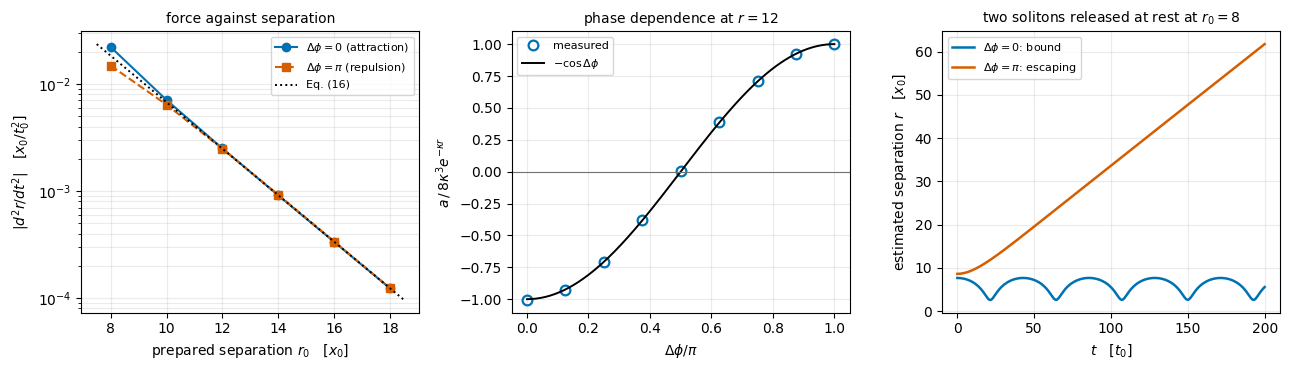

phase scan at r = 12: max |a/(8 kappa^3 e^-kr) + cos(dphi)| = 0.007
in-phase pair : estimated r falls from 7.682 to 2.603 at t = 21.0 and is back at 7.685 at t = 43.0
                maxima of r(t) at t = [ 43.  86. 128. 171.]  ->  period 42.7
                Eq. (16) released at rest at r_0 = 8 predicts 42.4 (ratio 1.006); with the prefactor 4 it would be 60.0
out-of-phase  : r grows monotonically from 8.634 to 61.743 at t = 200
CHECKPOINT 8 passed: in phase the pair is bound, with the period Eq. (16) predicts; out of phase it flies apart.


In [19]:
# ==============================================================================
# THE PHASE DEPENDENCE OF THE FORCE, and two long runs that show where it leads
# ==============================================================================
PHI_SCAN = np.linspace(0.0, np.pi, 9)
D_FIX = 12.0
psi0_scan = np.stack([two_solitons(x, D_FIX / 2, G, N_1, N_2, 0.0, 0.0, p_) for p_ in PHI_SCAN])
FR_SCAN = np.asarray(force_run(jnp.asarray(psi0_scan)))

a_scan = []
for idx in range(len(PHI_SCAN)):
    r_t = separation(FR_SCAN[idx], x, L)
    n_fit = NFR_F // 3
    a_scan.append(2.0 * np.polyfit(t_force[:n_fit], r_t[:n_fit], 2)[0])
a_scan = np.array(a_scan)
a_unit = 8.0 * KAP_1 ** 3 * np.exp(-KAP_1 * D_FIX)               # at the prepared separation

# two long runs at d = 8: bound oscillation vs escape
T_LONG, NFR_L = 200.0, 200
nin_L = int(round((T_LONG / NFR_L) / 0.01))
t_long = np.arange(NFR_L + 1) * (T_LONG / NFR_L)
long_run = jax.jit(jax.vmap(lambda p: split_step_frames(p, k_j, G, V_ZERO,
                                                        (T_LONG / NFR_L) / nin_L, nin_L, NFR_L)))
FR_LONG = np.asarray(long_run(jnp.asarray(np.stack([
    two_solitons(x, 4.0, G, N_1, N_2, 0.0, 0.0, 0.0),
    two_solitons(x, 4.0, G, N_1, N_2, 0.0, 0.0, np.pi)]))))
r_bound = separation(FR_LONG[0], x, L)
r_escape = separation(FR_LONG[1], x, L)

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.8))
axes[0].semilogy(D_LIST, a_in, "o-", ms=6, color=C_NUM, lw=1.5, label=r"$\Delta\phi=0$ (attraction)")
axes[0].semilogy(D_LIST, a_out, "s--", ms=6, color=C_ANA, lw=1.5, label=r"$\Delta\phi=\pi$ (repulsion)")
r_fine = np.linspace(D_LIST.min() - 0.5, D_LIST.max() + 0.5, 100)
axes[0].semilogy(r_fine, 8 * KAP_1 ** 3 * np.exp(-KAP_1 * r_fine), "k:", lw=1.4, label=r"Eq. (16)")
axes[0].set_xlabel(r"prepared separation $r_0$   [$x_0$]"), axes[0].set_ylabel(r"$|d^2r/dt^2|$   [$x_0/t_0^2$]")
axes[0].set_title("force against separation", fontsize=10)
axes[0].grid(alpha=0.25, which="both"), axes[0].legend(fontsize=8)

axes[1].plot(PHI_SCAN / np.pi, a_scan / a_unit, "o", ms=7, color=C_NUM, mfc="none", mew=1.6,
             label="measured")
axes[1].plot(np.linspace(0, 1, 200), -np.cos(np.pi * np.linspace(0, 1, 200)), "k-", lw=1.4,
             label=r"$-\cos\Delta\phi$")
axes[1].axhline(0.0, color=C_GREY, lw=0.8)
axes[1].set_xlabel(r"$\Delta\phi/\pi$"), axes[1].set_ylabel(r"$a\,/\,8\kappa^3e^{-\kappa r}$")
axes[1].set_title(rf"phase dependence at $r={D_FIX:g}$", fontsize=10)
axes[1].grid(alpha=0.25), axes[1].legend(fontsize=8)

axes[2].plot(t_long, r_bound, color=C_NUM, lw=1.8, label=r"$\Delta\phi=0$: bound")
axes[2].plot(t_long, r_escape, color=C_ANA, lw=1.8, label=r"$\Delta\phi=\pi$: escaping")
axes[2].set_xlabel(r"$t$   [$t_0$]"), axes[2].set_ylabel(r"estimated separation $r$   [$x_0$]")
axes[2].set_title(r"two solitons released at rest at $r_0=8$", fontsize=10)
axes[2].grid(alpha=0.25), axes[2].legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"phase scan at r = {D_FIX:g}: max |a/(8 kappa^3 e^-kr) + cos(dphi)| = "
      f"{np.max(np.abs(a_scan / a_unit + np.cos(PHI_SCAN))):.3f}")

# The period of the bound pair. All four maxima of r(t) agree to three digits, so np.argmax would return
# an arbitrary one of them; the period is the spacing of SUCCESSIVE maxima, located by comparison with
# their neighbours.
loc_max = [i for i in range(1, NFR_L) if r_bound[i] > r_bound[i - 1] and r_bound[i] >= r_bound[i + 1]]
loc_min = [i for i in range(1, NFR_L) if r_bound[i] < r_bound[i - 1] and r_bound[i] <= r_bound[i + 1]]
T_pair_meas = float(np.mean(np.diff(t_long[np.array(loc_max)])))

# Eq. (16) integrated once for dphi = 0: energy conservation gives
#     (dr/dt)^2 = 16 kappa^2 [ exp(-kappa r) - exp(-kappa r_0) ]   for a pair released at rest at r_0,
# and the quadrature of dt = dr / |dr/dt| from r_0 down to r = 0 is elementary, so with w_0 = exp(-kappa r_0)
#     period = 2 * t_half = arctan( sqrt((1-w_0)/w_0) ) / (kappa^2 sqrt(w_0)).
R0_LONG = 8.0                                        # prepared separation of the two long runs
w_0 = np.exp(-KAP_1 * R0_LONG)
T_pair_pred = float(np.arctan(np.sqrt((1 - w_0) / w_0)) / (KAP_1 ** 2 * np.sqrt(w_0)))
T_pair_pred_4 = np.sqrt(2.0) * T_pair_pred           # the same quadrature with the prefactor 4 instead of 8

print(f"in-phase pair : estimated r falls from {r_bound[0]:.3f} to {r_bound[loc_min[0]]:.3f} at "
      f"t = {t_long[loc_min[0]]:.1f} and is back at {r_bound[loc_max[0]]:.3f} at t = {t_long[loc_max[0]]:.1f}")
print(f"                maxima of r(t) at t = {np.round(t_long[np.array(loc_max)], 1)}"
      f"  ->  period {T_pair_meas:.1f}")
print(f"                Eq. (16) released at rest at r_0 = {R0_LONG:g} predicts {T_pair_pred:.1f} "
      f"(ratio {T_pair_meas / T_pair_pred:.3f}); with the prefactor 4 it would be {T_pair_pred_4:.1f}")
print(f"out-of-phase  : r grows monotonically from {r_escape[0]:.3f} to {r_escape[-1]:.3f} at t = {T_LONG:g}")
assert r_bound.max() < 1.05 * r_bound[0] and r_escape[-1] > 5 * r_escape[0]
assert abs(T_pair_meas / T_pair_pred - 1) < 0.05, "the bound-pair period must follow Eq. (16)"
assert abs(T_pair_meas / T_pair_pred_4 - 1) > 0.2, "a prefactor 4 must be excluded"
print("CHECKPOINT 8 passed: in phase the pair is bound, with the period Eq. (16) predicts; "
      "out of phase it flies apart.")

The left panel is Eq. (16) drawn against the measurement over a factor $e^{5} = 148$ in the force: attraction
in phase, repulsion out of phase, the same exponential in both. The middle panel is the $\cos\Delta\phi$,
with the measured accelerations normalised by $8\kappa^{3}e^{-\kappa r}$ and no fitted parameter at all; the
largest deviation from $-\cos\Delta\phi$ anywhere in the scan is $0.007$.

The right panel follows the consequence for $200$ time units, for two pairs prepared at $r_0 = 8$ (the
half-space estimator reads $7.68$ and $8.63$). The in-phase pair falls together until the two lumps merge
(estimated separation $2.6$ at $t=21$), separates again to $7.685$ at $t=43$ — its initial estimate to three
digits — and starts over: a bound two-soliton state, whose successive maxima at $t=43, 86, 128, 171$ give a
period of $42.7$. Nothing damps it, because nothing in Eq. (1) can radiate away from a two-soliton
bound state: the state is (up to the $e^{-\kappa r}$ of Section 2.2) an exact solution of the integrable
equation, the "breather" of the two-soliton family. The out-of-phase pair flies apart, to an estimated
$61.7$ after the same $200$ time units, its separation growing linearly once the exponential force has
died.

That period is not an extra fact: Eq. (16) contains it. For $\Delta\phi=0$ the equation is one-dimensional
motion in the potential $-8\kappa^{2}e^{-\kappa r}$ per unit reduced mass, so a pair released at rest at
$r_0$ has $(\dot r)^{2} = 16\kappa^{2}\left[e^{-\kappa r}-e^{-\kappa r_0}\right]$ and the time to fall from
$r_0$ to contact is the elementary quadrature printed in the cell above; the period of $r(t)$ is twice it,

$$ T_{\rm pair} \;=\; \frac{e^{\kappa r_0/2}}{\kappa^{2}}\,\arctan\sqrt{e^{\kappa r_0}-1}
   \;\xrightarrow[\ \kappa r_0\gg1\ ]{}\; \frac{\pi}{2\kappa^{2}}\,e^{\kappa r_0/2} . $$

For $r_0 = 8$ that is $42.4$ against the measured $42.7$, although the law is used down to complete overlap,
where it fails: the pair spends most of each period near the turning point $r_0$, where Eq. (16) holds. Had
the prefactor been $4$ instead of $8$, the same formula would have predicted $60.0$, and the cell asserts that
this is excluded. A prefactor $4$ read off a source that uses the *half* separation is the standard way to get
this wrong.

> **Physics insight.** At $\Delta\phi = \pi/2$ the force vanishes, and the interaction does something else
> instead: the two solitons exchange *amplitude* rather than momentum. That is the second half of the
> Karpman-Solov'ev two-soliton equations — the separation is driven by $\cos\Delta\phi$ and the amplitude
> difference by $\sin\Delta\phi$ — and it is why a soliton pair in a fibre with a quadrature phase relation
> drifts in power rather than in position.

## 8. Unequal solitons

### 8.1 The centre-of-mass sum rule

Nothing so far required $N_1=N_2$. For unequal solitons Eq. (11) predicts two *different* shifts, and they are
not independent: the centre of mass constrains them. Ehrenfest's relation for Eq. (1) is
$d\langle x\rangle/dt = p$ with $p$ conserved (00c, Section 4.4), so $\langle x\rangle$ is exactly linear in
$t$ — through the collision and everything in it. Writing the field as two solitons plus negligible radiation,

$$ \langle x\rangle(t) \;=\; N_1x_1(t) + N_2x_2(t) , $$

and inserting the asymptotic forms of Eq. (9) before and after the collision, the terms linear in $t$ match
automatically (momentum conservation), and the constants match only if

$$ \boxed{\;N_1\,\Delta x_1 \;+\; N_2\,\Delta x_2 \;=\; 0\;} . \tag{17} $$

Equation (11) satisfies Eq. (17) identically, since $N_j \propto \kappa_j$ and $\Delta x_2 =
-(\kappa_1/\kappa_2)\Delta x_1$: the lighter soliton is displaced further, in inverse proportion to its norm,
as the centre of mass of any two bodies requires. This is a prediction about the two measured numbers that
does not go through Eq. (11) at all, so it is an independent test.

### 8.2 The measurement

The runs below are done in the centre-of-mass frame, $N_1k_1 + N_2k_2 = 0$, with a fixed relative velocity
$\Delta k = k_1-k_2 = 2\times$ the main velocity, so that only the mass ratio changes. The initial
half-separation is raised to $x_0 = 24$ because the lighter soliton is wider — its $\kappa_1$ is smaller — and
the accuracy floor of Eq. (6) is set by $e^{-\kappa_{\min}d}$.

In [20]:
# ==============================================================================
# CHECKPOINT 9: unequal solitons -- two different shifts, one sum rule
# ==============================================================================
X0_UNEQ = 24.0
N1_LIST = np.array([0.50, 0.45, 0.40, 0.35, 0.30])
DK_UNEQ = 2.0 * K_MAIN

print(f"{'N_1':>5s} {'N_2':>5s} {'k_1':>8s} {'k_2':>8s} {'dx_1':>10s} {'Eq.(11)':>10s} "
      f"{'dx_2':>10s} {'Eq.(11)':>10s} {'sum rule':>10s}")
rows_u = []
for n1 in N1_LIST:
    n2 = 1.0 - n1
    kap1, kap2 = n1 * G / 2, n2 * G / 2
    k1 = DK_UNEQ * n2                 # so that n1 k1 + n2 k2 = 0 and k1 - k2 = DK_UNEQ
    k2 = -DK_UNEQ * n1
    T_u = 4.0 * X0_UNEQ / DK_UNEQ     # collision at T/2, final separation = initial separation
    nfr_u, nin_u = 100, 40
    dt_u = (T_u / nfr_u) / nin_u
    t_u = np.arange(nfr_u + 1) * (T_u / nfr_u)
    fr_u = np.asarray(split_step_frames(
        jnp.asarray(two_solitons(x, X0_UNEQ, G, n1, n2, k1, k2, 0.0)),
        k_j, G, V_ZERO, dt_u, nin_u, nfr_u))
    c1, c2 = track_pair(fr_u, t_u, x, dx, L, -X0_UNEQ + k1 * t_u, X0_UNEQ + k2 * t_u, HALF_WIDTH)
    d1, _, _ = asymptote_shift(t_u, c1)
    d2, _, _ = asymptote_shift(t_u, c2)
    p1 = shift_analytic(kap1, kap2, DK_UNEQ)
    p2 = -shift_analytic(kap1, kap2, DK_UNEQ) * kap1 / kap2
    rows_u.append((n1, d1, d2, p1, p2, n1 * d1 + n2 * d2))
    print(f"{n1:5.2f} {n2:5.2f} {k1:8.5f} {k2:8.5f} {d1:10.6f} {p1:10.6f} {d2:10.6f} {p2:10.6f} "
          f"{n1 * d1 + n2 * d2:10.2e}")

rows_u = np.array(rows_u)
print(f"\nlargest |measured - Eq. (11)|          : "
      f"{np.max(np.abs(rows_u[:, 1:3] - rows_u[:, 3:5])):.2e}")
print(f"largest |N_1 dx_1 + N_2 dx_2| (Eq. (17)): {np.max(np.abs(rows_u[:, 5])):.2e}")
assert np.max(np.abs(rows_u[:, 1:3] - rows_u[:, 3:5])) < 2e-3
assert np.max(np.abs(rows_u[:, 5])) < 2e-3
print("CHECKPOINT 9 passed: unequal solitons obey Eq. (11) and the sum rule (17).")

  N_1   N_2      k_1      k_2       dx_1    Eq.(11)       dx_2    Eq.(11)   sum rule


 0.50  0.50  0.41888 -0.41888   1.771479   1.771522  -1.771479  -1.771522   1.32e-12
 0.45  0.55  0.46077 -0.37699   1.937321   1.936919  -1.584591  -1.584752   2.70e-04


 0.40  0.60  0.50265 -0.33510   2.075002   2.075832  -1.384166  -1.383888  -4.99e-04
 0.35  0.65  0.54454 -0.29322   2.186985   2.186020  -1.176945  -1.177088   4.30e-04


 0.30  0.70  0.58643 -0.25133   2.268501   2.267988  -0.972034  -0.971995   1.26e-04

largest |measured - Eq. (11)|          : 9.65e-04
largest |N_1 dx_1 + N_2 dx_2| (Eq. (17)): 4.99e-04
CHECKPOINT 9 passed: unequal solitons obey Eq. (11) and the sum rule (17).


For a mass ratio of $7:3$ the light soliton is pushed forward by $2.2685$ and the heavy one backward by
$0.9720$: the ratio $2.2685/0.9720 = 2.334$ is the inverse mass ratio $0.7/0.3 = 2.333$, as Eq. (17) demands.
Both shifts agree with Eq. (11) to at worst $1.0\times10^{-3}$ and the sum rule holds to $5\times10^{-4}$,
with no systematic trend in the mass ratio. Those residuals are larger than the few $10^{-5}$ of the equal
solitons in Section 10.2; they change by comparable amounts when $\Delta t$ is divided by four or the
tracking window is widened, so they measure how well the lighter, wider soliton is tracked at this step size.
The symmetric row $N_1=N_2$, where both shifts are forced to be mirror images by parity, satisfies the sum
rule to $10^{-12}$.

Nothing else changes. The collision is still elastic; the light soliton comes out light and the heavy one
heavy. That is the content of "the eigenvalues $\zeta_j$ are conserved" — in the integrable equation a big
soliton cannot eat a small one.

## 9. Breaking integrability

### 9.1 A quintic term and a barrier

Everything above rests on Eq. (1) being *exactly* the cubic nonlinear Schrödinger equation. Integrability is
not robust: it is a property of that one equation, and almost any extra term destroys it. Two physically
motivated perturbations:

* a **quintic** term. A real quasi-one-dimensional condensate is not one-dimensional. When the density rises,
  the transverse cloud contracts, which strengthens the effective interaction; expanding that effect in the
  density produces an attractive $\vert\psi\vert^{4}\psi$ term. It is also the term that makes a
  one-dimensional equation collapse, since $\int\vert\psi\vert^{6}dx$ scales as $w^{-2}$, exactly like the
  kinetic energy (00c, Section 6.2, with $d=1$ and a quintic nonlinearity in place of the cubic one).
* a **Gaussian barrier**, $V(x) = V_0e^{-x^{2}/2\sigma_b^{2}}$, placed at the collision point. An external
  potential breaks translation invariance, so momentum is no longer conserved and the inverse-scattering
  machinery is gone.

The perturbed equation is

$$ i\,\frac{\partial\psi}{\partial t} \;=\; -\frac{1}{2}\frac{\partial^{2}\psi}{\partial x^{2}}
   \;-\; g\vert\psi\vert^{2}\psi \;-\; g_5\vert\psi\vert^{4}\psi \;+\; V(x)\,\psi , \tag{18} $$

and the propagator needs one extra term in the position-space factor, whose exponent becomes
$i\left(g\vert\psi\vert^{2} + g_5\vert\psi\vert^{4} - V\right)\Delta t$. The position-space factor is still a
pure phase, so the step is still exactly unitary and the norm is still conserved to round-off, whatever
Eq. (18) does to the physics.

In [21]:
# ==============================================================================
# STEP 4: the propagator for the perturbed equation (18)
#   One line differs from _split_step_body: the exponent of the position-space factor.
# ==============================================================================
def _perturbed_body(k, g, g5, V, dt):
    """One Strang step for Eq. (18). Still unitary: the middle factor is a pure phase."""
    exp_kin = jnp.exp(-0.25j * k ** 2 * dt)

    def step(psi, _):
        psi = jnp.fft.ifft(exp_kin * jnp.fft.fft(psi))
        rho = jnp.abs(psi) ** 2
        psi = psi * jnp.exp(1j * (g * rho + g5 * rho ** 2 - V) * dt)
        return jnp.fft.ifft(exp_kin * jnp.fft.fft(psi)), None
    return step


@partial(jax.jit, static_argnames=("n_inner", "n_frames"))
def perturbed_frames(psi, k, g, g5, V, dt, n_inner, n_frames):
    """split_step_frames for Eq. (18): snapshots every n_inner steps, shape (n_frames+1, N_x)."""
    step = _perturbed_body(k, g, g5, V, dt)

    def outer(psi, _):
        psi, _ = lax.scan(step, psi, None, length=n_inner)
        return psi, psi

    _, frames = lax.scan(outer, psi, None, length=n_frames)
    return jnp.concatenate([psi[None, :], frames], axis=0)


print("STEP 4: perturbed_frames ready (quintic coefficient g5 and an external potential V).")

STEP 4: perturbed_frames ready (quintic coefficient g5 and an external potential V).


In [22]:
# ==============================================================================
# THE QUINTIC SWEEP: 3 coupling strengths x 5 relative phases, one vmapped program
# ==============================================================================
G5_LIST = np.array([0.0, 2.0, 4.0])
PHI_Q = np.array([0.0, 0.25, 0.5, 0.75, 1.0]) * np.pi
NFR_Q, NIN_Q = 80, 240
dt_q = (T_MAIN / NFR_Q) / NIN_Q
t_q = np.arange(NFR_Q + 1) * (T_MAIN / NFR_Q)

grid_g5 = np.array([g5 for g5 in G5_LIST for _ in PHI_Q])
grid_ph = np.array([pp for _ in G5_LIST for pp in PHI_Q])
psi0_q = np.stack([two_solitons(x, X0, G, N_1, N_2, K_MAIN, -K_MAIN, pp) for pp in grid_ph])

quint_run = jax.jit(jax.vmap(lambda p, g5: perturbed_frames(p, k_j, G, g5, V_ZERO,
                                                            dt_q, NIN_Q, NFR_Q)))
t_wall = time.time()
FR_Q = np.asarray(quint_run(jnp.asarray(psi0_q), jnp.asarray(grid_g5)))
print(f"{len(grid_g5)} runs x {NIN_Q * NFR_Q} steps, vmapped: {time.time() - t_wall:.2f} s"
      f"   -> array {FR_Q.shape}, dt = {dt_q:.6f}")

15 runs x 19200 steps, vmapped: 10.11 s   -> array (15, 81, 1024), dt = 0.004974


In [23]:
# ==============================================================================
# CHECKPOINT 10: the collision stops being elastic
#   N_left, N_right : norm in the two moving windows at the end
#   N_centre        : norm left behind within |x| < 6   (a merged lump, if there is one)
#   radiation       : everything else
# ==============================================================================
print(f"{'g5':>5s} {'dphi/pi':>8s} {'N_left':>9s} {'N_right':>9s} {'transfer':>10s} "
      f"{'N_centre':>9s} {'radiation':>10s} {'max density':>12s} {'norm-1':>10s}")
rows_q = []
for idx in range(len(grid_g5)):
    frs = FR_Q[idx]
    cl_ = soliton_centre(frs[-1], x, L, -X0 + K_MAIN * t_q[-1], HALF_WIDTH)
    cr_ = soliton_centre(frs[-1], x, L, X0 - K_MAIN * t_q[-1], HALF_WIDTH)
    n_l = window_norm(frs[-1], x, dx, L, cl_, HALF_WIDTH)
    n_r = window_norm(frs[-1], x, dx, L, cr_, HALF_WIDTH)
    n_c = window_norm(frs[-1], x, dx, L, 0.0, 6.0)
    rad = 1.0 - n_l - n_r - n_c
    rows_q.append((grid_g5[idx], grid_ph[idx], n_l, n_r, n_c, rad, float(np.max(np.abs(frs) ** 2))))
    print(f"{grid_g5[idx]:5.1f} {grid_ph[idx] / np.pi:8.2f} {n_l:9.6f} {n_r:9.6f} {n_r - n_l:10.2e} "
          f"{n_c:9.6f} {rad:10.3e} {np.max(np.abs(frs) ** 2):12.5f} "
          f"{grid_norm(frs[-1], dx) - 1:10.2e}")

rows_q = np.array(rows_q)
int_rows = rows_q[rows_q[:, 0] == 0.0]
print(f"\nintegrable rows (g5 = 0): largest norm transfer {np.max(np.abs(int_rows[:, 3] - int_rows[:, 2])):.2e}, "
      f"largest radiation {int_rows[:, 5].max():.2e}")
q2 = rows_q[rows_q[:, 0] == 2.0]
q4 = rows_q[rows_q[:, 0] == 4.0]
print(f"g5 = 2: transfer up to {np.max(np.abs(q2[:, 3] - q2[:, 2])):.4f}, "
      f"radiation from {q2[:, 5].min():.4f} (out of phase) to {q2[:, 5].max():.4f} (in phase)")
print(f"g5 = 4: in-phase run leaves {q4[0, 4]:.4f} of the norm at the centre "
      f"(the two solitons merged); out-of-phase run leaves {q4[-1, 4]:.4f}")
assert np.max(np.abs(int_rows[:, 3] - int_rows[:, 2])) < 1e-5, "the integrable rows must transfer nothing"
assert np.max(np.abs(q2[:, 3] - q2[:, 2])) > 0.05, "the quintic term must transfer norm"
assert q4[0, 4] > 0.5 > q4[-1, 4], "in phase the quintic pair merges, out of phase it does not"
print("CHECKPOINT 10 passed: one extra term turns elastic scattering into everything else.")

   g5  dphi/pi    N_left   N_right   transfer  N_centre  radiation  max density     norm-1
  0.0     0.00  0.499994  0.499994   3.38e-12  0.000000  1.200e-05      0.49607  -1.62e-09
  0.0     0.25  0.499994  0.499994  -7.01e-07  0.000000  1.200e-05      0.46596  -1.14e-09
  0.0     0.50  0.499994  0.499994  -7.29e-07  0.000000  1.199e-05      0.39521   5.52e-12
  0.0     0.75  0.499994  0.499994  -3.90e-07  0.000000  1.199e-05      0.31427   1.15e-09
  0.0     1.00  0.499994  0.499994   3.42e-12  0.000000  1.199e-05      0.24120   1.63e-09
  2.0     0.00  0.471335  0.471335   8.73e-12  0.016987  4.034e-02      0.69410  -1.62e-09
  2.0     0.25  0.420602  0.542674   1.22e-01  0.007585  2.914e-02      0.63219  -1.14e-09
  2.0     0.50  0.433942  0.550937   1.17e-01  0.001841  1.328e-02      0.49849   5.34e-12
  2.0     0.75  0.464387  0.529859   6.55e-02  0.000744  5.010e-03      0.36947   1.15e-09
  2.0     1.00  0.498252  0.498252   4.20e-12  0.000572  2.923e-03      0.26699   1.63e-09

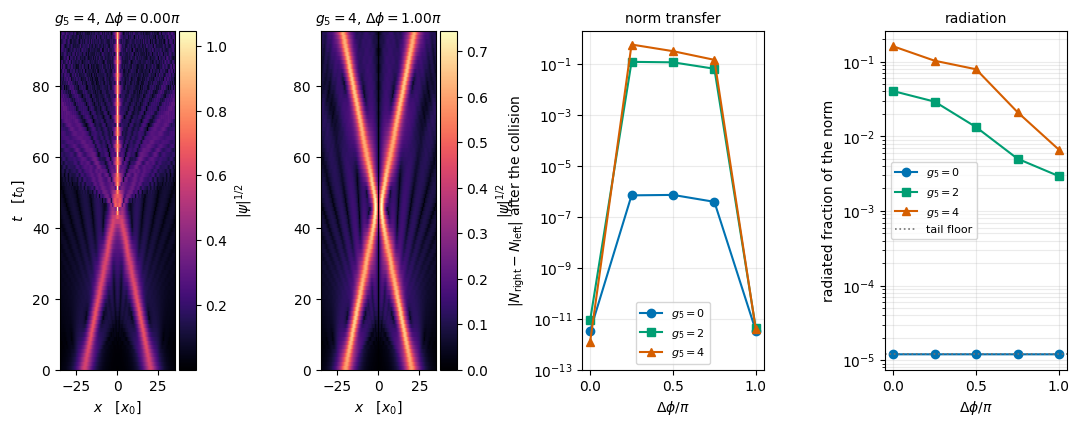

In [24]:
# ==============================================================================
# FIGURE: what the quintic term does, seen and measured
# ==============================================================================
fig = plt.figure(figsize=(13.0, 4.4))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1.3, 1.3], wspace=0.75)

for panel, idx in enumerate([10, 14]):                 # g5 = 4, in phase and out of phase
    axn = fig.add_subplot(gs[0, panel])
    im = axn.imshow(np.abs(FR_Q[idx]) ** 0.5, origin="lower", aspect="auto", cmap="magma",
                    extent=[-L / 2, L / 2, 0, T_MAIN], interpolation="nearest")
    axn.set_xlim(-35, 35), axn.set_xlabel(r"$x$   [$x_0$]")
    if panel == 0:
        axn.set_ylabel(r"$t$   [$t_0$]")
    axn.set_title(rf"$g_5=4$, $\Delta\phi={grid_ph[idx] / np.pi:.2f}\pi$", fontsize=10)
    fig.colorbar(im, ax=axn, pad=0.03, label=r"$|\psi|^{1/2}$")

axn = fig.add_subplot(gs[0, 2])
for g5v, col, mk in zip(G5_LIST, [C_NUM, C_THIRD, C_ANA], ["o", "s", "^"]):
    sel = rows_q[:, 0] == g5v
    axn.plot(rows_q[sel, 1] / np.pi, np.abs(rows_q[sel, 3] - rows_q[sel, 2]), mk + "-", ms=6,
             color=col, lw=1.5, label=rf"$g_5={g5v:g}$")
axn.set_yscale("log"), axn.set_ylim(1e-13, 2.0)
axn.set_xlabel(r"$\Delta\phi/\pi$"), axn.set_ylabel(r"$|N_{\rm right}-N_{\rm left}|$ after the collision")
axn.set_title("norm transfer", fontsize=10)
axn.grid(alpha=0.25, which="both"), axn.legend(fontsize=8)

axn = fig.add_subplot(gs[0, 3])
for g5v, col, mk in zip(G5_LIST, [C_NUM, C_THIRD, C_ANA], ["o", "s", "^"]):
    sel = rows_q[:, 0] == g5v
    axn.plot(rows_q[sel, 1] / np.pi, rows_q[sel, 5], mk + "-", ms=6, color=col, lw=1.5,
             label=rf"$g_5={g5v:g}$")
axn.axhline(2 * tail_floor, color=C_GREY, ls=":", lw=1.2, label="tail floor")
axn.set_yscale("log")
axn.set_xlabel(r"$\Delta\phi/\pi$"), axn.set_ylabel("radiated fraction of the norm")
axn.set_title("radiation", fontsize=10)
axn.grid(alpha=0.25, which="both"), axn.legend(fontsize=8)
plt.show()

The two maps are the same in-phase and out-of-phase collision as in Section 6, with $g_5=4$. Out of phase the
picture is barely changed: the node keeps the two solitons from ever reaching a high density, they pass
through with $0.496$ of the norm each, and $0.66\%$ is radiated. In phase they do not come out at all. The
density spike at the crossing reaches $1.20$, ten times the single-soliton peak, which is enough for the
quintic term to bind the two solitons together; what leaves the collision is a single lump at the origin
holding $78.5\%$ of the norm, plus $16.1\%$ of radiation spraying outwards in both directions and only
$2.7\%$ left in each of the two outgoing windows.

The two right-hand panels quantify the whole sweep.

* **Norm transfer.** With $g_5=0$ the two outgoing norms differ by at most $7\times10^{-7}$ at every phase —
  the integrable result of Section 6, here at a nearly five times smaller time step than the sweep of that
  section ($0.00497$ against $0.02387$).
  With $g_5=2$ the difference reaches $0.122$, and with $g_5=4$ it reaches $0.584$: one soliton leaves the
  collision with $71\%$ of the atoms and the other with $12\%$. The transfer vanishes at $\Delta\phi=0$ and
  $\Delta\phi=\pi$ for a reason that has nothing to do with integrability — the state has definite parity,
  so the two halves are mirror images at every time — and is largest in between.
* **Radiation.** The integrable curve sits flat on the analytic tail floor, $1.2\times10^{-5}$. The perturbed
  ones rise by $2.4$ to $4.1$ orders of magnitude and are strongly phase-dependent: in phase the collision
  radiates $4.0\%$ ($g_5=2$) and $16.1\%$ ($g_5=4$), out of phase only $0.29\%$ and $0.66\%$.

> **Physics insight.** This is the one-dimensional caricature of what Parker, Martin, Cornish and Adams
> computed in the full three-dimensional Gross-Pitaevskii equation (J. Phys. B **41**, 045303 (2008)): in-phase
> collisions of bright solitary waves drive the density up at the crossing point, and if the density stays
> high for longer than the collapse time the pair is destroyed, while out-of-phase collisions keep a node
> between the waves and survive. Nguyen, Dyke, Luo, Malomed and Hulet saw the phase dependence in the
> laboratory (Nature Physics **10**, 918 (2014)). The mechanism here is not collapse — one dimension with a
> cubic nonlinearity has none — but the quintic term stands in for the transverse degree of freedom that makes
> collapse possible, and the phase selectivity is the same.

In [25]:
# ==============================================================================
# THE SECOND PERTURBATION: a Gaussian barrier at the collision point
# ==============================================================================
SIG_B = 1.0
V0_LIST = np.array([0.05, 0.10, 0.20])
print(f"incident kinetic energy per particle k^2/2 = {K_MAIN ** 2 / 2:.5f}")
print(f"{'V_0':>6s} {'V_0/(k^2/2)':>12s} {'dphi/pi':>8s} {'N_left':>9s} {'N_right':>9s} "
      f"{'radiation':>10s} {'v_out/k-1':>11s}")
for V0 in V0_LIST:
    V_bar = jnp.asarray(V0 * np.exp(-x ** 2 / (2 * SIG_B ** 2)))
    for dp in (0.0, np.pi):
        fr_b = np.asarray(perturbed_frames(
            jnp.asarray(two_solitons(x, X0, G, N_1, N_2, K_MAIN, -K_MAIN, dp)),
            k_j, G, 0.0, V_bar, dt_q, NIN_Q, NFR_Q))
        cl_b, cr_b = track_pair(fr_b, t_q, x, dx, L, -X0 + K_MAIN * t_q, X0 - K_MAIN * t_q, HALF_WIDTH)
        n_l = window_norm(fr_b[-1], x, dx, L, cl_b[-1], HALF_WIDTH)
        n_r = window_norm(fr_b[-1], x, dx, L, cr_b[-1], HALF_WIDTH)
        late_b = t_q > 0.8 * T_MAIN
        v_b = float(np.polyfit(t_q[late_b], cl_b[late_b], 1)[0])
        print(f"{V0:6.2f} {V0 / (K_MAIN ** 2 / 2):12.3f} {dp / np.pi:8.2f} {n_l:9.6f} {n_r:9.6f} "
              f"{1 - n_l - n_r - window_norm(fr_b[-1], x, dx, L, 0.0, 6.0):10.3e} {v_b / K_MAIN - 1:11.2e}")

incident kinetic energy per particle k^2/2 = 0.08773
   V_0  V_0/(k^2/2)  dphi/pi    N_left   N_right  radiation   v_out/k-1


  0.05        0.570     0.00  0.499935  0.499935  1.286e-04   -2.91e-04


  0.05        0.570     1.00  0.499986  0.499986  2.692e-05   -2.69e-05


  0.10        1.140     0.00  0.499648  0.499648  6.980e-04   -1.81e-03


  0.10        1.140     1.00  0.499973  0.499973  5.124e-05   -8.79e-05


  0.20        2.280     0.00  0.497925  0.497925  4.090e-03   -1.07e-02


  0.20        2.280     1.00  0.499943  0.499943  1.094e-04   -2.43e-04


The barrier is a weaker perturbation at these parameters but works the same way. At $V_0 = 0.2$, which is
$2.3$ times the incident kinetic energy per particle, the in-phase collision radiates $4.1\times10^{-3}$ of
the norm against $1.1\times10^{-4}$ out of phase — a factor of $37$ between the two phases — and the outgoing
velocity is $1.1\%$ below $k$ in phase against $0.02\%$ out of phase. Momentum is not conserved once there is
an external potential, so there is no reason for the velocity to come back at all; what the barrier takes
depends on how long the pair dwells on it, and the in-phase pair, which piles its density onto the barrier,
dwells longer. Exercise 2 pushes the barrier until the soliton splits.

## 10. Numerical practice

### 10.1 Resolution: how fine a grid a fast soliton needs

The Fourier transform of $\mathrm{sech}(\kappa u)$ is again a $\mathrm{sech}$,

$$ \int \mathrm{sech}(\kappa u)\,e^{-iqu}du \;=\; \frac{\pi}{\kappa}\,
   \mathrm{sech}\!\left(\frac{\pi q}{2\kappa}\right) , $$

so a soliton boosted to velocity $k_0$ has a spectrum centred on $k_0$ and falling as
$e^{-\pi\vert q-k_0\vert/(2\kappa)}$. Requiring that the spectrum has fallen below a tolerance $\varepsilon$
at the Nyquist wave number $k_{\max} = \pi/\Delta x$ of the grid (rule 2 of notebook 00a) gives

$$ \frac{\pi}{\Delta x} \;\gtrsim\; \vert k_0\vert \;+\; \frac{2\kappa}{\pi}\,\ln\frac{2}{\varepsilon} . \tag{19} $$

For $\kappa=0.5$, $k_0 = 0.42$ and $\varepsilon = 10^{-6}$ this asks for $k_{\max}\gtrsim 5.0$, i.e.
$N_x \gtrsim 192$ on $L=120$; for $\varepsilon=10^{-14}$ it asks for $k_{\max}\gtrsim11$, i.e.
$N_x\gtrsim 420$. The cost grows only as $\vert k_0\vert$ and as $\kappa\ln(1/\varepsilon)$, which is why
spectral methods are comfortable here: a soliton ten times faster does not need a grid ten times finer, only
one whose Nyquist wave number still clears $\vert k_0\vert$ by the same margin — at $k_0=4.19$ Eq. (19) asks
for $k_{\max}\gtrsim 8.8$ against $5.04$ at $k_0=0.42$, i.e. a grid $1.75$ times finer, not ten times.

> **Numerical practice.** On a periodic grid the usable band is $\vert q\vert \le \pi/\Delta x$, and a
> *boosted* object occupies the band around its own $k_0$. Before choosing $N_x$, add the
> carrier $\vert k_0\vert$ to the intrinsic bandwidth of the envelope — here $(2\kappa/\pi)\ln(2/\varepsilon)$
> from the $\mathrm{sech}$ spectrum — and demand $\pi/\Delta x$ above the sum, Eq. (19). Whatever crosses
> $\pi/\Delta x$ is aliased back to the opposite edge of the band and reappears as a
> counter-propagating wave: the $N_x=128$ row of the table below is wrong by $7.6\%$ and shows no sign of
> being wrong other than disagreeing with the finer grids.

### 10.2 Convergence in $\Delta x$ and $\Delta t$, and the price of the ring

In [26]:
# ==============================================================================
# CONVERGENCE STUDY 1: the measured shift against N_x and against dt
# ==============================================================================
d_ref = shift_analytic(KAP_1, KAP_2, 2 * K_MAIN)

print(f"(a) grid refinement at fixed dt, L = {L:g}   [Eq. (11): {d_ref:.8f}]")
print(f"{'N_x':>6s} {'dx':>8s} {'k_max':>8s} {'Eq.(19) needs':>14s} {'dx measured':>13s} {'error':>11s}")
need = abs(K_MAIN) + 2 * KAP_1 / np.pi * np.log(2e6)
for n_pts in (128, 192, 256, 384, 512, 1024):
    xg, kg, dxg = make_grid(L, n_pts)
    p0g = (soliton_exact(xg, 0.0, G, x_c=-X0, k_0=K_MAIN, n=N_1)
           + soliton_exact(xg, 0.0, G, x_c=X0, k_0=-K_MAIN, n=N_2))
    nfr_g, nin_g = 100, 24
    dt_g = (T_MAIN / nfr_g) / nin_g
    t_g = np.arange(nfr_g + 1) * (T_MAIN / nfr_g)
    fr_g = np.asarray(split_step_frames(jnp.asarray(p0g), jnp.asarray(kg), G,
                                        jnp.zeros(n_pts, dtype=RDTYPE), dt_g, nin_g, nfr_g))
    cg = np.array([soliton_centre(p, xg, L, gg, HALF_WIDTH)
                   for p, gg in zip(fr_g, -X0 + K_MAIN * t_g)])
    dg, _, _ = asymptote_shift(t_g, cg)
    print(f"{n_pts:6d} {dxg:8.4f} {np.pi / dxg:8.3f} {need:14.3f} {dg:13.7f} {dg - d_ref:+11.2e}")

dt_rk4 = 2.0 * np.sqrt(2.0) / ((np.pi / dx) ** 2 / 2.0)     # 00c, Eq. (43): the RK4 limit on this grid
print(f"\n(b) time step at fixed N_x = {N_X}  "
      f"(an explicit RK4 integrator would be limited to dt = {dt_rk4:.5f} here, 00c Eq. (43))")
print(f"{'dt':>9s} {'dt/dt_RK4':>10s} {'dx measured':>13s} {'error':>11s} {'max|E(t)-E(0)|':>16s} {'ratio':>8s}")
prev_e = None
for nin_t in (5, 10, 20, 40):
    dt_t = (T_MAIN / 100) / nin_t
    t_t = np.arange(101) * (T_MAIN / 100)
    fr_t = np.asarray(split_step_frames(jnp.asarray(psi0_main), k_j, G, V_ZERO, dt_t, nin_t, 100))
    ct = np.array([soliton_centre(p, x, L, gg, HALF_WIDTH) for p, gg in zip(fr_t, -X0 + K_MAIN * t_t)])
    dt_meas, _, _ = asymptote_shift(t_t, ct)
    e_t = np.array([gp_energy(p, k, dx, G) for p in fr_t])
    drift = float(np.max(np.abs(e_t - e_t[0])))
    print(f"{dt_t:9.5f} {dt_t / dt_rk4:10.1f} {dt_meas:13.7f} {dt_meas - d_ref:+11.2e} {drift:16.3e} "
          f"{(prev_e / drift if prev_e else float('nan')):8.3f}")
    prev_e = drift

print(f"\n(c) initial separation (this is the real limit)")
print(f"{'x_0':>6s} {'exp(-kappa 2x_0)':>18s} {'dx measured':>13s} {'error':>11s}")
for x0_try in (12.0, 16.0, 20.0, 24.0):
    nfr_s, nin_s = 100, 40
    T_s = 2 * x0_try / K_MAIN
    dt_s = (T_s / nfr_s) / nin_s
    t_s = np.arange(nfr_s + 1) * (T_s / nfr_s)
    fr_s = np.asarray(split_step_frames(
        jnp.asarray(two_solitons(x, x0_try, G, N_1, N_2, K_MAIN, -K_MAIN, 0.0)),
        k_j, G, V_ZERO, dt_s, nin_s, nfr_s))
    cs = np.array([soliton_centre(p, x, L, gg, HALF_WIDTH)
                   for p, gg in zip(fr_s, -x0_try + K_MAIN * t_s)])
    ds, _, _ = asymptote_shift(t_s, cs)
    print(f"{x0_try:6.1f} {np.exp(-KAP_1 * 2 * x0_try):18.3e} {ds:13.7f} {ds - d_ref:+11.2e}")

(a) grid refinement at fixed dt, L = 120   [Eq. (11): 1.77152213]
   N_x       dx    k_max  Eq.(19) needs   dx measured       error
   128   0.9375    3.351          5.037     1.9060737   +1.35e-01


   192   0.6250    5.027          5.037     1.7711818   -3.40e-04
   256   0.4688    6.702          5.037     1.7715087   -1.34e-05


   384   0.3125   10.053          5.037     1.7715375   +1.53e-05


   512   0.2344   13.404          5.037     1.7715469   +2.47e-05
  1024   0.1172   26.808          5.037     1.7715371   +1.49e-05

(b) time step at fixed N_x = 1024  (an explicit RK4 integrator would be limited to dt = 0.00787 here, 00c Eq. (43))
       dt  dt/dt_RK4   dx measured       error   max|E(t)-E(0)|    ratio


  0.19099       24.3     1.7712285   -2.94e-04        4.516e-04      nan
  0.09549       12.1     1.7714305   -9.17e-05        1.148e-04    3.932


  0.04775        6.1     1.7715263   +4.12e-06        2.880e-05    3.987
  0.02387        3.0     1.7715531   +3.10e-05        7.207e-06    3.997

(c) initial separation (this is the real limit)
   x_0   exp(-kappa 2x_0)   dx measured       error


  12.0          6.144e-06     2.2971253   +5.26e-01
  16.0          1.125e-07     1.7721591   +6.37e-04


  20.0          2.061e-09     1.7715531   +3.10e-05
  24.0          3.775e-11     1.7714794   -4.27e-05


Panel (a). At $N_x=128$ the Nyquist wave number is $3.35$, below the $5.04$ that Eq. (19) asks for, and the
measured shift is wrong by $0.135$ — $7.6\%$. At $N_x=192$, whose $k_{\max}=5.03$ sits right on the
threshold, the error drops to $3.4\times10^{-4}$, and from $N_x=256$ on it sits between $1$ and
$2.5\times10^{-5}$ and stops improving. Spectral convergence is a cliff at the point where the grid starts
to represent the state, followed by a plateau, and Eq. (19) locates the cliff to within
one doubling of $N_x$.

Panel (b). Halving the time step divides the energy drift by four each time (ratios $3.93$, $3.99$, $4.00$):
the $O(\Delta t^{2})$ of Strang splitting, measured. The shift converges at the same rate but from a much
lower starting point — it moves only from $1.77123$ to $1.77155$ as $\Delta t$ falls by eight, an absolute
change of $3\times10^{-4}$ — and the coarsest step tried, $\Delta t = 0.191$, is $24$ times the stability
limit an explicit integrator would have had on this grid (00c, Eq. (43)), printed in the header of the table.
Unconditional stability is what makes such a step legal; the measurement is what makes it acceptable.

Panel (c). The initial separation is the third constraint, and it is not a discretisation at all. At $x_0=12$
the "two solitons" of Eq. (4) overlap enough that the object propagated is measurably not a pair of free
solitons, and the measured shift is $2.297$ against the predicted $1.772$ — an error of $30\%$, with a
perfectly converged grid and time step. At $x_0=16$ the error is $6\times10^{-4}$, and from $x_0=20$ on it
is a few times $10^{-5}$ and stops falling, because by then the residuals of panels (a) and (b) are the
larger of the three. (These runs all take the same number of steps, so a larger $x_0$ also means a longer
run and a larger $\Delta t$; that is why $x_0=24$ is not better than $x_0=20$.)

> **Numerical practice.** Three separate convergence parameters, three separate behaviours, and the one that
> dominates is the one that is not a numerical parameter at all. Refining $\Delta x$ and $\Delta t$ on a run
> started from too small an $x_0$ would have produced beautifully converged numbers for the wrong problem.

### 10.3 The ring brings them back

The solitons live on a circle, so after the collision they keep going and meet again on the far side. The
second collision happens once the relative coordinate has covered another $L$, i.e. after a further
$L/\Delta k$, and it is *not* at the free-motion time, because each soliton is already displaced by
$\Delta x$ from the first collision. The cell below runs long enough to see both, and checks the arithmetic.

first collision  : measured t = 45.76
   incoming asymptotes cross at 47.75, outgoing at 43.52, mean 45.63
second collision : measured t = 185.02
   free motion would put it at 189.00; corrected for the first shift, 184.77
peak density at the two collisions: 0.49917 and 0.49260
CHECKPOINT 11 passed: the recurrence time follows from the shift.


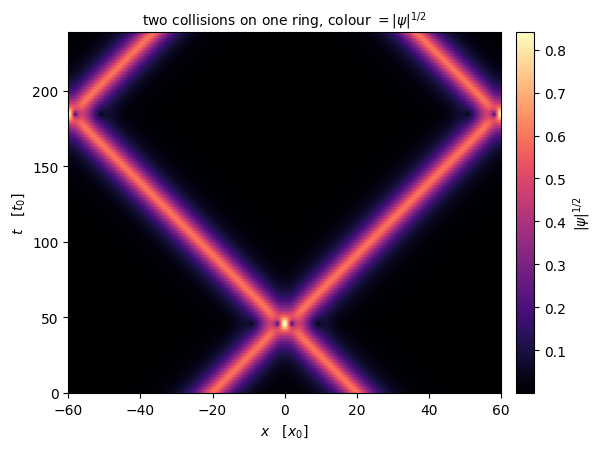

In [27]:
# ==============================================================================
# CHECKPOINT 11: two collisions on one ring, and the timing of the second
# ==============================================================================
T_RING = 4.0 * X0 / (2 * K_MAIN) + L / (2 * K_MAIN)
NFR_R = 240
nin_R = int(round((T_RING / NFR_R) / 0.01))
t_ring = np.arange(NFR_R + 1) * (T_RING / NFR_R)
fr_ring = np.asarray(split_step_frames(jnp.asarray(psi0_main), k_j, G, V_ZERO,
                                       (T_RING / NFR_R) / nin_R, nin_R, NFR_R))
peak_t = np.max(np.abs(fr_ring) ** 2, axis=1)

# the two local maxima of the peak density are the two collisions
i1 = int(np.argmax(peak_t[: NFR_R // 2]))
i2 = int(NFR_R // 2 + np.argmax(peak_t[NFR_R // 2:]))
t_in = X0 / K_MAIN                                   # crossing of the INCOMING asymptotes
t_out = (X0 - d_ref) / K_MAIN                        # crossing of the OUTGOING asymptotes
print(f"first collision  : measured t = {t_ring[i1]:.2f}")
print(f"   incoming asymptotes cross at {t_in:.2f}, outgoing at {t_out:.2f}, mean {0.5 * (t_in + t_out):.2f}")
print(f"second collision : measured t = {t_ring[i2]:.2f}")
print(f"   free motion would put it at {t_ring[i1] + L / (2 * K_MAIN):.2f}; "
      f"corrected for the first shift, {t_ring[i1] + (L - 2 * d_ref) / (2 * K_MAIN):.2f}")
print(f"peak density at the two collisions: {peak_t[i1]:.5f} and {peak_t[i2]:.5f}")
assert abs(t_ring[i1] - 0.5 * (t_in + t_out)) < 1.5
assert abs(t_ring[i2] - t_ring[i1] - (L - 2 * d_ref) / (2 * K_MAIN)) < 1.5
print("CHECKPOINT 11 passed: the recurrence time follows from the shift.")

fig, ax = plt.subplots(figsize=(6.2, 4.6))
im = ax.imshow(np.abs(fr_ring) ** 0.5, origin="lower", aspect="auto", cmap="magma",
               extent=[-L / 2, L / 2, 0, T_RING], interpolation="nearest")
ax.set_xlabel(r"$x$   [$x_0$]"), ax.set_ylabel(r"$t$   [$t_0$]")
ax.set_title(r"two collisions on one ring, colour $=|\psi|^{1/2}$", fontsize=10)
fig.colorbar(im, ax=ax, pad=0.03, label=r"$|\psi|^{1/2}$")
fig.tight_layout()
plt.show()

The map shows the two ridges crossing at $t = 45.8$ near $x=0$ and again at $t = 185.0$ at the seam
$x=\pm60$, where the periodic boundary joins the picture to itself. The first crossing sits between the
crossing of the incoming asymptotes ($47.75$) and that of the outgoing ones ($43.52$) and, to within the
frame spacing of $1.0$, on their mean ($45.63$). The second crossing arrives earlier than free motion
predicts ($189.0$) by $2\Delta x/(2k) = 4.2$ time units, because each soliton had already been pushed forward
by $\Delta x$ in the first collision; the shift-corrected prediction is $184.8$ against the measured $185.0$.
The shift also changes the clock.

> **Numerical practice.** Choose $L$ and $T$ together. The useful window is
> $T < (L-2x_0)/\Delta k$ after the first collision; beyond it the "isolated pair" the measurement assumes no
> longer exists. Enlarging $L$ costs $O(N_x\log N_x)$ per step at fixed $\Delta x$, which is cheap, so there is
> rarely a reason to economise on the ring.

### 10.4 Cost

Every run in this notebook is $2$ FFTs of length $N_x$ per step, i.e. $O(N_x\log N_x)$ time and $O(N_x)$
memory, with no linear system and no stability limit. The two sweeps were run with `vmap`, which turns
$n$ independent runs into one compiled program operating on a batched array; the arithmetic is the same, but
it is issued once instead of $n$ times and the compilation happens once instead of $n$ times.

In [28]:
# ==============================================================================
# PERFORMANCE: one collision, compiled once, timed separately from the compilation
# ==============================================================================
n_bench = 20000
args = (jnp.asarray(psi0_main), k_j, G, V_ZERO, 0.005)
t0 = time.time()
_ = split_step_evolve(*args, n_bench).block_until_ready()
t_compile_and_run = time.time() - t0
t0 = time.time()
_ = split_step_evolve(*args, n_bench).block_until_ready()
t_run = time.time() - t0
print(f"N_x = {N_X}, {n_bench} split-step iterations")
print(f"   first call (compile + run): {t_compile_and_run:.3f} s")
print(f"   second call (run only)    : {t_run:.3f} s  -> {1e6 * t_run / n_bench:.2f} us per step, "
      f"{1e9 * t_run / (n_bench * N_X):.2f} ns per grid point per step")
t0 = time.time()
_ = jax.block_until_ready(sweep_run(jnp.asarray(psi0_sweep), jnp.asarray(DT_LIST)))
t_sweep = time.time() - t0
print(f"   the 10-velocity vmapped sweep, already compiled: {t_sweep:.3f} s for "
      f"{len(K_LIST) * NIN_SW * NFR_SW} steps -> {1e6 * t_sweep / (len(K_LIST) * NIN_SW * NFR_SW):.2f} us "
      f"per step-equivalent")

N_x = 1024, 20000 split-step iterations
   first call (compile + run): 0.881 s
   second call (run only)    : 0.820 s  -> 40.99 us per step, 40.02 ns per grid point per step


   the 10-velocity vmapped sweep, already compiled: 1.273 s for 40000 steps -> 31.83 us per step-equivalent


## 11. Animations

The function below is the one written in notebook 00a and reused in 00c: `FuncAnimation` updates artists
created once, `PillowWriter` encodes the frames, the GIF is written to a temporary directory that deletes
itself, and the bytes are emitted as **one output carrying two representations** — a plain `image/gif` for
Jupyter and the GitHub notebook viewer, and a base64 `<img>` tag for static website renderers, which drop
`image/gif` outputs. Every animation below is backed by a static figure elsewhere in the notebook, because an
animation cannot be read quantitatively.

In [29]:
# ==============================================================================
# STEP 5: "stack of curves -> embedded animated GIF"  (copied from notebook 00a, Section 10)
# ==============================================================================
def make_density_gif(x, densities, times, overlay=None, mean_x=None, envelope=None, band=None,
                     title="", xlabel=r"$x$  [$x_0$]", ylabel=r"$|\psi(x,t)|^2$", time_label=r"t",
                     ylim=None, fill=True, label_num="numerics", label_ana="analytic",
                     fps=12, dpi=72, figsize=(7.2, 3.3)):
    """Animate a stack of curves and embed the result as an animated GIF in the notebook output.

    ARGUMENTS
        x          : (N_x,)            the grid
        densities  : (n_frames, N_x)   the quantity drawn as a filled curve (usually |psi|^2)
        times      : (n_frames,)       the label of each frame
        overlay    : (n_frames, N_x)   optional reference curve, drawn dashed
        mean_x     : (n_frames,)       optional marker on the x-axis
        envelope   : (n_frames, N_x)   optional thin grey curves at +/- envelope
        band       : (n_frames, 2)     optional horizontal bar [x_lo, x_hi]
    IMPLEMENTATION
        FuncAnimation -> PillowWriter -> a temporary file -> bytes -> one display() carrying BOTH
        an "image/gif" and a base64 "<img>" text/html representation of the same animation.
    """
    densities = np.asarray(densities)
    n_frames = len(times)
    if ylim is None:
        lo, hi = float(densities.min()), float(densities.max())
        pad = 0.12 * (hi - lo)
        ylim = (lo - pad, hi + pad)

    fig, ax = plt.subplots(figsize=figsize)
    patch = ax.fill_between(x, 0, densities[0], color=C_NUM, alpha=0.35, lw=0) if fill else None
    (line_num,) = ax.plot(x, densities[0], color=C_NUM, lw=1.9, label=label_num)
    line_ana = ax.plot(x, overlay[0], color=C_ANA, lw=1.8, ls="--", label=label_ana)[0] if overlay is not None else None
    if envelope is not None:
        (line_env_p,) = ax.plot(x, envelope[0], color=C_GREY, lw=0.9)
        (line_env_m,) = ax.plot(x, -envelope[0], color=C_GREY, lw=0.9)
    bar = ax.plot(band[0], [ylim[0], ylim[0]], color="k", lw=2.5, solid_capstyle="butt",
                  clip_on=False, label=r"$\langle x\rangle \pm \sigma$")[0] if band is not None else None
    marker = ax.plot([mean_x[0]], [ylim[0]], marker="^", ms=9, color="k",
                     clip_on=False, ls="none", label=r"$\langle x\rangle$")[0] if mean_x is not None else None
    txt = ax.text(0.015, 0.90, "", transform=ax.transAxes, fontsize=11,
                  bbox=dict(boxstyle="round", fc="w", ec="0.7", alpha=0.85))
    ax.set_xlim(x[0], x[-1] + (x[1] - x[0])), ax.set_ylim(*ylim)
    ax.set_xlabel(xlabel), ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
    fig.tight_layout()                                    # otherwise the x-label is cut off in the GIF

    def update(i):
        nonlocal patch
        if patch is not None:
            patch.remove()                                # a filled area cannot be updated: redraw it
            patch = ax.fill_between(x, 0, densities[i], color=C_NUM, alpha=0.35, lw=0)
        line_num.set_ydata(densities[i])
        if line_ana is not None:
            line_ana.set_ydata(overlay[i])
        if envelope is not None:
            line_env_p.set_ydata(envelope[i]), line_env_m.set_ydata(-envelope[i])
        if bar is not None:
            bar.set_data(band[i], [ylim[0], ylim[0]])
        if marker is not None:
            marker.set_data([mean_x[i]], [ylim[0]])
        txt.set_text(f"${time_label} = {times[i]:6.2f}$")
        return ()

    anim = FuncAnimation(fig, update, frames=n_frames, interval=1000 / fps, blit=False)
    with tempfile.TemporaryDirectory() as tmpdir:         # the directory (and the GIF) vanish afterwards
        path = os.path.join(tmpdir, "anim.gif")
        anim.save(path, writer=PillowWriter(fps=fps), dpi=dpi)
        with open(path, "rb") as fh:
            gif_bytes = fh.read()
    plt.close(fig)                                        # no duplicate static image
    b64 = base64.b64encode(gif_bytes).decode("ascii")
    tag = f'<img src="data:image/gif;base64,{b64}" alt="animation" style="max-width:100%;height:auto">'
    display({"image/gif": b64, "text/html": tag}, raw=True)   # two representations, one output
    print(f"   [{n_frames} frames, {len(gif_bytes) / 1e6:.2f} MB embedded in the notebook]")
    return len(gif_bytes)


print("make_density_gif is ready.")

make_density_gif is ready.


### 11.1 In phase against out of phase

The same collision twice, drawn on the same axes: solid blue for $\Delta\phi=0$, dashed orange for
$\Delta\phi=\pi$. Watch the moment of overlap. The blue curve builds one tall peak; the orange curve keeps two
lumps with a node between them that never fills in. Watch the two curves *after* the collision: they are on
top of each other again.

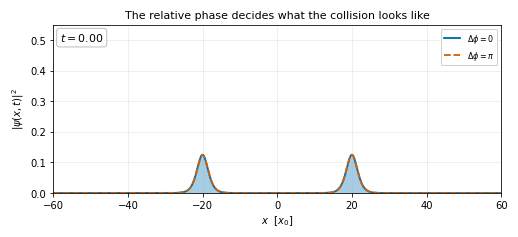

   [51 frames, 0.22 MB embedded in the notebook]


In [30]:
# ==============================================================================
# ANIMATION 1: relative phase 0 against pi
# ==============================================================================
sub = slice(None, None, 4)                                   # 51 of the 201 stored frames
n_bytes = make_density_gif(x, np.abs(FR_PHASE[0][sub]) ** 2, t_ph[sub],
                           overlay=np.abs(FR_PHASE[-1][sub]) ** 2,
                           ylim=(0.0, 0.55),
                           label_num=r"$\Delta\phi=0$", label_ana=r"$\Delta\phi=\pi$",
                           title=r"The relative phase decides what the collision looks like")
assert n_bytes < 1_500_000

The two runs are indistinguishable except in the few time units around $t\approx45$, where the in-phase
density builds a single peak (reaching $0.4978$ at its highest, $0.33$ in the frame at $t=47.75$) while the
out-of-phase density splits into two lumps separated by an exact zero. Afterwards the two curves lie on top
of each other again — the same two solitons, in the same places, as the table of Section 6 measured.

### 11.2 A fast collision against a slow one

Two collisions with a factor of six between their relative velocities. They last different lengths of time, so
the common clock is $t/t_{\rm coll}$, the time in units of each run's own free collision time: both pairs
start at $\mp x_0$ at $t/t_{\rm coll}=0$, collide at $1$, and end at $\pm x_0$ at $2$.

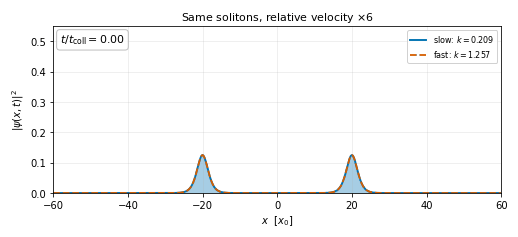

   [51 frames, 0.24 MB embedded in the notebook]
   shift: slow 3.8040, fast 0.2939 (ratio 12.94)


In [31]:
# ==============================================================================
# ANIMATION 2: fast (k = 1.257) against slow (k = 0.209), on a common collision clock
# ==============================================================================
j_slow, j_fast = 0, 8                                        # indices into K_LIST
sub2 = slice(None, None, 2)                                  # 51 of the 101 stored frames
clock = np.arange(NFR_SW + 1) / (NFR_SW / 2)                 # t / t_coll, 0 .. 2
n_bytes = make_density_gif(x, np.abs(FR_SWEEP[j_slow][sub2]) ** 2, clock[sub2],
                           overlay=np.abs(FR_SWEEP[j_fast][sub2]) ** 2,
                           ylim=(0.0, 0.55), time_label=r"t/t_{\rm coll}",
                           label_num=rf"slow: $k={K_LIST[j_slow]:.3f}$",
                           label_ana=rf"fast: $k={K_LIST[j_fast]:.3f}$",
                           title=r"Same solitons, relative velocity $\times 6$")
assert n_bytes < 1_500_000
print(f"   shift: slow {rows_v[j_slow, 1]:.4f}, fast {rows_v[j_fast, 1]:.4f} "
      f"(ratio {rows_v[j_slow, 1] / rows_v[j_fast, 1]:.2f})")

Both pairs cover the same distance in the same number of frames, because the clock is normalised and not the
velocity. What differs physically is the collision itself. The fast pair produces a finely striped
interference pattern — the fringe spacing is $2\pi/\Delta k = 2.5$ length units at $\Delta k = 2.51$ — whose
envelope is narrow because the two solitons are only briefly on top of each other; the slow pair, at
$\Delta k = 0.42$, spends long enough in contact to merge into one broad lump of half the peak density. And
the slow pair comes out displaced by $3.804$ against $0.294$ for the fast one, a factor of $12.9$.

### 11.3 A non-integrable collision: merging and radiation

The in-phase collision with the quintic term of Eq. (18), against the integrable run as a reference. On a
logarithmic density scale, so that the radiation is visible.

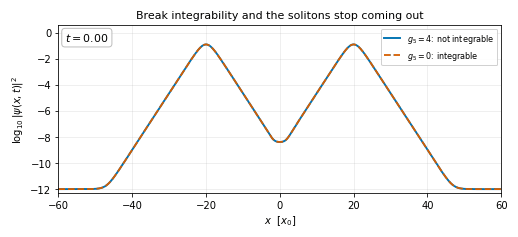

   [41 frames, 0.47 MB embedded in the notebook]
   median density at |x| > 30 in the last frame: 1.58e-03 (g5 = 4) vs 4.12e-11 (g5 = 0)
   central lump at the end (g5 = 4): peak density 0.7496 at x = +0.00


In [32]:
# ==============================================================================
# ANIMATION 3: a non-integrable collision -- merging and radiation
# ==============================================================================
sub3 = slice(None, None, 2)                                  # 41 of the 81 stored frames
dens_q = np.log10(np.abs(FR_Q[10][sub3]) ** 2 + 1e-12)       # g5 = 4, in phase
dens_ref = np.log10(np.abs(FR_Q[0][sub3]) ** 2 + 1e-12)      # g5 = 0, in phase
n_bytes = make_density_gif(x, dens_q, t_q[sub3], overlay=dens_ref,
                           ylim=(-12.3, 0.6), fill=False,
                           ylabel=r"$\log_{10}|\psi(x,t)|^2$",
                           label_num=r"$g_5=4$: not integrable", label_ana=r"$g_5=0$: integrable",
                           title=r"Break integrability and the solitons stop coming out")
assert n_bytes < 1_500_000

far = np.abs(x) > 30.0                                       # neither soliton, neither merged lump
print(f"   median density at |x| > 30 in the last frame: "
      f"{np.median(np.abs(FR_Q[10][-1][far]) ** 2):.2e} (g5 = 4) vs "
      f"{np.median(np.abs(FR_Q[0][-1][far]) ** 2):.2e} (g5 = 0)")
print(f"   central lump at the end (g5 = 4): peak density {np.max(np.abs(FR_Q[10][-1]) ** 2):.4f} at "
      f"x = {x[int(np.argmax(np.abs(FR_Q[10][-1]) ** 2))]:+.2f}")

The orange reference is the integrable collision: two lumps in, two lumps out, eight decades
of clean $\mathrm{sech}^{2}$ tail on each. The blue curve does not. At the crossing the density climbs past
the integrable one, the two solitons stick, and what is left afterwards is a single lump at the origin, of
peak density about $0.75$ — six times a soliton's — sitting in a background of radiation that fills the whole
ring. The printed median density beyond $\vert x\vert = 30$ puts that background at $1.6\times10^{-3}$
against $4.1\times10^{-11}$ for the reference run, whose $\mathrm{sech}^{2}$ tails are all there is out
there — a factor of $4\times10^{7}$.

## 12. Summary

### 12.1 Key takeaways

* **Solitons scatter like particles, and "like particles" is a measurement.** After a head-on collision each
  soliton has its norm back to $5\times10^{-9}$, its analytic $\mathrm{sech}$ shape back to $10^{-6}$ of the
  peak, its velocity back to $1.4\times10^{-6}$ in relative terms, and the radiated norm is below the
  $1.23\times10^{-5}$ floor set by the tails of the solitons themselves. In a nonlinear equation with no
  superposition principle, that is a remarkable thing for two lumps to do, and it is the reason the word
  *soliton* exists.
* **The whole collision is two numbers.** A position shift and a phase jump, Eqs. (11) and (13). The measured
  shift follows the inverse-scattering formula to between $3\times10^{-6}$ and $1.8\times10^{-4}$ in relative
  terms over a factor of eight in velocity, and the phase jump follows $2\arctan(\kappa/k)$ to between
  $1.6\times10^{-5}$ and $1.1\times10^{-3}$ radians, the residual falling as $\Delta t^{2}$.
* **The shift is forwards.** The focusing nonlinearity makes solitons attract, so each one leaves the
  collision ahead of where free motion would have put it — by $3.804$ length units, nearly two widths, at the
  slowest velocity tried, and by $0.171$ at the fastest.
* **The relative phase controls the picture; the outcome does not depend on it.** In phase, the density at the crossing reaches
  $0.4978$, which is $0.9956$ of the constructive-interference value $4\kappa^{2}/g$; out of phase, parity
  forces an exact node at the origin for all time. Yet the outgoing norms differ by at most
  $1.8\times10^{-5}$ and the position shift varies by $2.3\times10^{-4}$ in relative terms across the whole
  range of $\Delta\phi$, and both residuals shrink with $\Delta t$, so they come from the integrator.
* **Neighbouring solitons exert an exponential force.** Measured:
  $d^{2}r/dt^{2} = -8\kappa^{3}e^{-\kappa r}\cos\Delta\phi$, with the rate $\kappa$ predicted by the
  tail-overlap argument and fitted to $-0.501$ and $-0.499$ from the two phases, the prefactor $8\kappa^{3}$
  confirmed to $0.8\%$ for $r \ge 12$ (and recovered from the half-separation form of the standard
  perturbation theory), and the $\cos\Delta\phi$ confirmed to $0.007$ with no free parameter. In phase
  a pair released at rest at $r_0=8$ oscillates with a period of $42.7$ against the $42.4$ that one
  quadrature of Eq. (16) predicts; out of phase it flies apart.
* **Unequal solitons obey a sum rule.** $N_1\Delta x_1 + N_2\Delta x_2 = 0$, which follows from momentum
  conservation alone and holds to $5\times10^{-4}$; the light soliton is displaced further, in inverse
  proportion to its norm ($2.2685$ against $0.9720$ for a $3{:}7$ mass ratio).
* **Integrability is fragile, and losing it is visible immediately.** A quintic term of strength $g_5=4$
  turns the in-phase collision into a merger that keeps $78.5\%$ of the norm in one lump and radiates
  $16.1\%$, while the out-of-phase collision at the same $g_5$ still passes through with $0.66\%$ radiated.
  At intermediate phases the two solitons exchange up to $58\%$ of their norm. All three effects are zero, to
  the accuracy of the measurement, when $g_5=0$.
* **Three convergence parameters, and the dangerous one is not numerical.** The grid converges spectrally
  once $k_{\max}$ clears the bound of Eq. (19) and the time step converges as $\Delta t^{2}$; but a *sum* of
  two solitons is a solution of Eq. (1) only to $O(e^{-\kappa d})$, and at $x_0=12$ that alone costs $30\%$
  in the measured shift with a perfectly converged grid and step. At $x_0=20$ the shift is within
  $3\times10^{-5}$ of Eq. (11), and the other two parameters set that residual.

### 12.2 Exercises

**1. (★) Three solitons.** Extend `two_solitons` to a list of $(N_j, x_j, k_j, \varphi_j)$ and launch three
solitons of norms $0.2$, $0.3$, $0.5$ with velocities chosen so that all three collisions are well separated
in time. Verify that the total shift of each soliton is the sum of its pairwise shifts from Eq. (11) — one of
the sharpest consequences of integrability, and one that a numerical experiment can test in ten lines. Check
the three-body version of the sum rule, $\sum_j N_j\Delta x_j = 0$. Enlarge the ring first: the accuracy
floor of Eq. (6) is set by the *smallest* $\kappa$, here $\kappa = N g/2 = 0.2$, so Section 10.2(c) demands
pairwise separations of order $80$ rather than $40$, and $L=120$ is not enough — $L = 400$ with
$N_x = 4096$ keeps $\Delta x$ and the cost per step where they are now.

**2. (★) A soliton beam splitter.** Send a single soliton of norm $1$ at a Gaussian barrier
$V(x) = V_0e^{-x^{2}/2\sigma_b^{2}}$ with $\sigma_b$ smaller than the soliton width, using `perturbed_frames`
with $g_5=0$. Scan $V_0$ at fixed incident velocity and measure the transmitted and reflected norms. Find the
$V_0$ that gives a $50{:}50$ split, and check whether the two outgoing pieces are still solitons (measure
their peak density against $\kappa^{2}/g$ with the *new* norms). This is the beam splitter of a soliton
interferometer.

**3. (★★) The higher-order soliton and its period.** The initial condition $\psi(x,0) = 2\phi_1(x)$, i.e. the
unit-norm soliton of 00c with its amplitude doubled (its norm is then $4$, not $1$: doubling the amplitude of
a fixed profile quadruples the norm, so this one experiment leaves the unit-norm convention of the notebook),
is not a soliton: Satsuma and Yajima showed that
$A\,\mathrm{sech}$ with $A$ an integer multiple of the fundamental amplitude is an $N$-soliton *bound state*
which breathes periodically (Prog. Theor. Phys. Suppl. **55**, 284 (1974)). Its period is set by the
difference of the two chemical potentials of the bound eigenvalues. Propagate it, measure the period of the
peak density, and compare with the value you get by identifying the two discrete eigenvalues from the
amplitudes of the two constituent solitons at the moment of maximum separation. The textbook quotes the
answer as the "soliton period" $\pi/2$ of fibre optics; check that this needs no conversion at all in the
time units of this notebook, by running the dictionary of Section 5.2 backwards. Watch the resolution: at
half a period the state compresses to four times its initial peak density and a correspondingly broader
spectrum.

**4. (★★) Chirped collisions.** Multiply one of the two solitons by $e^{i\alpha x^{2}}$ before the collision,
i.e. give it a spatially varying velocity ("chirp"). The chirped object is no longer a soliton, so the
initial condition contains a soliton plus radiation. Measure how much norm survives as a soliton against
$\alpha$, and check that the surviving soliton still collides elastically with the unchirped one.

**5. (★★) Newton's cradle.** Build a train of five equally spaced solitons at rest, all in phase, and
propagate. The nearest-neighbour attraction of Eq. (16) makes the outer pairs fall inwards first. Measure the
positions and ask whether the motion resembles the classical Newton's cradle — and why the answer is "no"
for an integrable system, in which nothing can be transferred except position. Then add a small $g_5$ and
repeat.

**6. (★★) The collision time.** Section 10.3 measured that the density peak sits between the crossing of the
incoming and the outgoing asymptotes. Derive the exact relation from the two-soliton solution in the limit
$\Delta k \gg \kappa$, where the two solitons barely deform, and test it against the measured collision times
over the velocity sweep of Section 5.3.

**7. (★★★) Solitons in a trap.** Add $V(x) = \tfrac12\omega^{2}x^{2}$ with $\omega = 0.03$ and release two
in-phase solitons at rest at $\pm 20$. They fall towards each other, collide, separate, and come back. (In the
soliton trains of Strecker *et al.*, Nature **417**, 150 (2002), neighbouring solitons oscillating in a shallow
trap did *not* pass through each other, which the authors read as a repulsion from alternating phases; repeat
the run with $\Delta\phi = \pi$ to see that case.) The trap breaks
translation invariance, so the collisions are no longer exactly elastic. Measure the norm radiated per
collision over ten collisions and find how it scales with $\omega$. Compare the oscillation period with
$2\pi/\omega$ and explain the difference using the shift of Eq. (11), as Section 10.3 did for the ring.

**8. (★★★) The two-soliton solution in closed form.** Look up or construct the exact two-soliton solution of
Eq. (1) by the Hirota bilinear method, evaluate it on the grid, and compare with the numerical propagation
during the overlap, where this notebook has no analytic reference at all. Then read the shifts of Eq. (11)
directly off its asymptotics instead of measuring them.

### 12.3 References

* N. J. Zabusky and M. D. Kruskal, *Interaction of "solitons" in a collisionless plasma and the recurrence of
  initial states*, Phys. Rev. Lett. **15**, 240 (1965) — the numerical experiment that found solitary waves
  surviving collisions, and named them.
* V. E. Zakharov and A. B. Shabat, *Exact theory of two-dimensional self-focusing and one-dimensional
  self-modulation of waves in nonlinear media*, Sov. Phys. JETP **34**, 62 (1972) — integrability of Eq. (1)
  by inverse scattering, and the multi-soliton solutions behind Eqs. (10)-(13).
* J. Satsuma and N. Yajima, *Initial value problems of one-dimensional self-modulation of nonlinear waves in
  dispersive media*, Prog. Theor. Phys. Suppl. **55**, 284 (1974) — how an arbitrary initial condition
  decomposes into solitons plus radiation, and the higher-order breathing solitons of Exercise 3.
* V. I. Karpman and V. V. Solov'ev, *A perturbational approach to the two-soliton systems*, Physica D **3**,
  487 (1981) — the perturbation theory for two overlapping solitons from which the half-separation form
  converted in Section 7.2 comes.
* J. P. Gordon, *Interaction forces among solitons in optical fibers*, Opt. Lett. **8**, 596 (1983) — the
  force between neighbouring solitons: exponential in their separation, sinusoidal in their relative phase.
* J. H. V. Nguyen, P. Dyke, D. Luo, B. A. Malomed and R. G. Hulet, *Collisions of matter-wave solitons*,
  Nature Physics **10**, 918 (2014) — collisions of lithium-7 solitons resolved by relative phase.
* K. E. Strecker, G. B. Partridge, A. G. Truscott and R. G. Hulet, *Formation and propagation of matter-wave
  soliton trains*, Nature **417**, 150 (2002) — a soliton train oscillating in a shallow trap, whose neighbours repel because
  of alternating relative phases (Exercise 7).
* N. G. Parker, A. M. Martin, S. L. Cornish and C. S. Adams, *Collisions of bright solitary matter waves*,
  J. Phys. B **41**, 045303 (2008) — the three-dimensional Gross-Pitaevskii calculation in which in-phase
  collisions trigger collapse and out-of-phase collisions do not.
* G. P. Agrawal, *Nonlinear Fiber Optics*, 5th ed., Academic Press (2013) — Chapter 5 (*Optical Solitons*)
  for the optical form of Eq. (1), its inverse-scattering solution and higher-order solitons; the appendix
  *Numerical Code for the NLS Equation* gives the split-step Fourier method as photonics uses it.
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes: The Art of Scientific
  Computing*, 3rd ed., Cambridge University Press (2007) — Chapter 12 (fast Fourier transform) and Chapter 20
  (partial differential equations, including operator splitting).
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes in Fortran 90: The
  Art of Parallel Scientific Computing*, 2nd ed. (Fortran Numerical Recipes, Volume 2), Cambridge University
  Press (1996) — the same material with parallel implementations of the FFT, which is the only operation
  this notebook performs in quantity.

### 12.4 What comes next

This is the last notebook of the wave-function-on-a-grid part of the course. Everything so far has been one
complex field on one grid, propagated with two FFTs per step, and the physics has been the physics of a single
orbital occupied by many particles. [01 — JAX](01_jax_from_scratch.ipynb) explains the tools
used on trust here — `jit`, `lax.scan`, `vmap`, and the rest — and
[02 — einsum from scratch](02_einsum_from_scratch.ipynb) the contraction notation the rest of the course
runs on. After them the course leaves the mean field
for the many-body Hilbert space, where the state is no longer a function of $x$ but a tensor with one index
per particle, and where no amount of grid refinement helps.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/